# 01. Introduction & Search Algorithms

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement and compare search algorithms (BFS, DFS, A*)
- Apply search to graphs and problem spaces

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 1, lessons 06-08 (BFS, DFS and A*) — the same three algorithms, now compared on one graph with complexity analysis and step-by-step visualisation.

**Used later in:** Course 02 — Unit 4, where "search the space for the best option" returns as numerical optimization.

---


# 01. Introduction & Search Algorithms

---

## The Story: Finding Your Way

Imagine you're a robot in a maze, trying to find the exit. **Before** using search algorithms, you wander randomly, maybe finding it by luck. **After** learning search algorithms, you systematically explore all possibilities and always find the optimal path!

---

## Why Python for AI?

Python's clear syntax makes AI concepts accessible:
- **Readability**: Code reads like natural language
- **Rich Ecosystem**: Libraries like NumPy, Pandas, Scikit-learn
- **Flexibility**: From simple algorithms to complex neural networks

## Learning Objectives
1. Understand Python basics for AI
2. Implement search algorithms (BFS, DFS, A*)
3. Visualize algorithms in action
4. See before/after comparisons
5. Understand how algorithms build on each other


## 🌍 The case: an algorithm built for one clumsy robot, now planning 55,000 delivery routes a day

**Menlo Park, 1968.** Peter Hart, Nils Nilsson and Bertram Raphael at SRI International were trying to get *Shakey* — the first mobile robot that planned its own actions — across a room full of obstacles. Blind search was hopeless on 1960s hardware. So they added an *estimate of the distance still to go* to the cost already paid, and then proved something valuable: as long as the estimate never overshoots the true remaining cost, the path you get back is still the shortest one. That is A\*, published as Hart, Nilsson & Raphael (1968) — reference 1 at the end of this notebook.

**2016.** UPS won INFORMS' Franz Edelman Award for **ORION** (On-Road Integrated Optimization and Navigation), the system that plans each driver's day across UPS's **55,000 US delivery routes**. UPS's reported figures at full deployment: about **100 million fewer miles driven** and **10 million fewer gallons of fuel** per year, worth an estimated **\$300–400 million annually** (INFORMS, 2016). ORION evaluates more than **200,000 alternative orderings** for a single driver's route before it prints one.

Forty-eight years apart, the same idea: don't look at every possibility — look at the promising ones first, and be able to state what guarantee you have when you stop.

### What goes wrong without this

A driver with 120 stops has 120! possible orderings — a number with 199 digits, vastly more than the atoms in the observable universe. Checking them all is not "slow"; it is impossible, this year and every year. Without a search algorithm you fall back on a habit — "always go to the nearest remaining stop" — which is fast, is sometimes badly wrong, and, crucially, **never tells you that it is wrong**.

The algorithms in this notebook buy you two things a habit cannot. They *terminate*. And each one comes with a stated guarantee: BFS returns the fewest edges, Dijkstra returns the lowest total cost, A\* returns the lowest total cost *if* its heuristic is honest, and DFS guarantees only that it found some path. Knowing which guarantee you are holding is the whole skill.

---


## Part 1: Setting the Scene

**Before**: We have a graph (network) of connected nodes. We need to find a path from start to goal.

**After**: We'll see how different search algorithms explore this graph differently!

**Common Student Questions:**
- **Q: What's the difference between BFS, DFS, and A*?**
  - Answer: BFS = level-by-level (queue), DFS = deep-first (stack), A* = smart search (heuristic)
  - BFS: Explores all neighbors before going deeper → finds shortest path
  - DFS: Goes as deep as possible → uses less memory
  - A*: Uses heuristic to guide search → faster, finds optimal path
- **Q: Why do we need different search algorithms?**
  - Answer: Different problems need different strategies
  - Shortest path? → BFS (unweighted) or A* (weighted)
  - Any path? → DFS (faster, less memory)
  - Optimal path with guidance? → A* (uses heuristic)
  - Each algorithm has trade-offs (speed vs memory vs optimality)
- **Q: What is a graph in AI?**
  - Answer: Graph = nodes (points) connected by edges (lines)
  - Nodes = states/positions, Edges = possible moves/connections
  - Example: Map (cities = nodes, roads = edges), Game (positions = nodes, moves = edges)
  - Search algorithms find paths through graphs

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us with data structures and visualization
from collections import deque  # For efficient queue operations (FIFO - First In First Out)
import heapq  # For priority queues (used in A* algorithm)
import matplotlib.pyplot as plt  # For creating visualizations
import matplotlib.patches as mpatches  # For drawing shapes
import numpy as np  # For numerical operations

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - collections.deque: Fast queue/stack operations")
print("   - heapq: Priority queue for A* algorithm")
print("   - matplotlib: Create beautiful graphs and visualizations")
print("   - numpy: Fast numerical computations")

✅ Libraries imported successfully!

📚 What each library does:
   - collections.deque: Fast queue/stack operations
   - heapq: Priority queue for A* algorithm
   - matplotlib: Create beautiful graphs and visualizations
   - numpy: Fast numerical computations


In [2]:
# Step 2: Define our problem - a simple graph
# Think of this as a map: each letter is a location, the list shows where you can go from there

# BEFORE: Just a dictionary definition
graph = {
    'A': ['B', 'C'],  # From A, you can go to B or C
    'B': ['D', 'E'],  # From B, you can go to D or E
    'C': ['F'],       # From C, you can go to F
    'D': [],          # D is a dead end (no connections)
    'E': ['G'],       # From E, you can go to G
    'F': [],          # F is a dead end
    'G': []           # G is our goal!
}

print("🗺️  Our Graph (Map):")
print("   Start: A")
print("   Goal: G")
print("\n📍 Connections:")
for node, neighbors in graph.items():
    if neighbors:
        print(f"   {node} -> {', '.join(neighbors)}")
    else:
        print(f"   {node} -> [end]")

🗺️  Our Graph (Map):
   Start: A
   Goal: G

📍 Connections:
   A -> B, C
   B -> D, E
   C -> F
   D -> [end]
   E -> G
   F -> [end]
   G -> [end]


📊 Visualizing the graph structure...


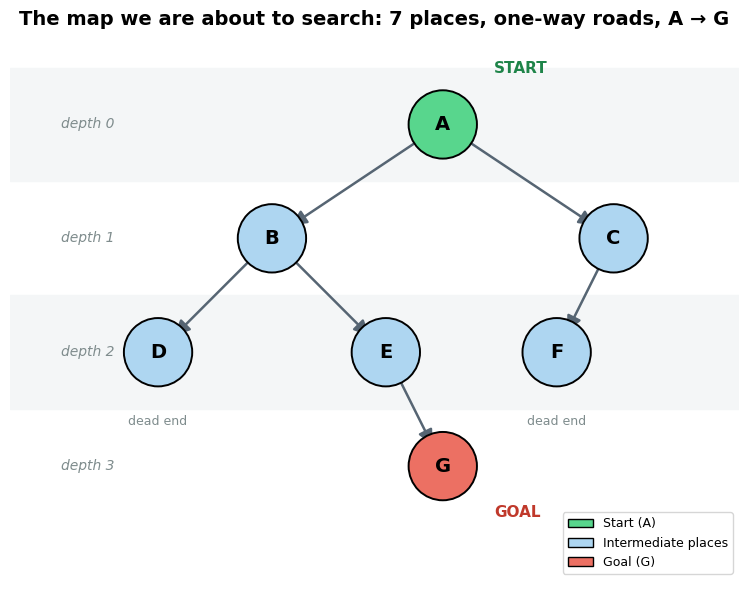


   depth 0 : ['A']  <- start
   depth 1 : ['B', 'C']
   depth 2 : ['D', 'E', 'F']
   depth 3 : ['G']  <- goal

✅ Graph visualized. The goal sits 3 roads away from the start, down one single route.


In [3]:
# Step 3: Visualize the graph BEFORE we start searching
# WHAT this cell does: draws the seven places and the one-way roads between them, and marks the
#   DEPTH of every place - how many roads away from the start it sits.
# WHY depth is drawn and not just the shape: BFS and DFS are two different orders of visiting these
#   same circles, and both orders are defined by depth. If you can see the four depth bands now,
#   every picture in the rest of this notebook reads as a movement between bands.

# Node coordinates reused by EVERY figure in this notebook, so all the pictures line up.
POS = {
    'A': (3, 3),    # depth 0 - the start
    'B': (1.5, 2),  # depth 1
    'C': (4.5, 2),  # depth 1
    'D': (0.5, 1),  # depth 2
    'E': (2.5, 1),  # depth 2
    'F': (4, 1),    # depth 2
    'G': (3, 0),    # depth 3 - the goal
}
COL_START, COL_GOAL, COL_MID = "#58d68d", "#ec7063", "#aed6f1"


def visualize_graph(graph, title="Graph Structure"):
    """Draw the graph: circles are places, arrows are one-way roads, bands are depth."""
    fig, ax = plt.subplots(figsize=(9, 6))

    # 1. Depth bands, drawn first so everything else sits on top of them.
    #    y = 3 - depth, exactly: A is at y=3, its neighbours at y=2, theirs at y=1, the goal at y=0.
    for depth, y in enumerate([3, 2, 1, 0]):
        if depth % 2 == 0:                                    # shade alternate bands so they read as bands
            ax.axhspan(y - 0.5, y + 0.5, color="#f4f6f7", zorder=0)
        ax.text(-0.35, y, f"depth {depth}", fontsize=10, ha='left', va='center',
                color="#7f8c8d", fontstyle='italic', zorder=1)

    # 2. Roads. shrinkA/shrinkB stop each arrow at the rim of the circle, so the ARROWHEAD stays
    #    visible instead of being buried under the node - that is what makes the roads one-way.
    for node, neighbours in graph.items():
        x1, y1 = POS[node]
        for neighbour in neighbours:
            x2, y2 = POS[neighbour]
            ax.annotate('', xy=(x2, y2), xytext=(x1, y1), zorder=2,
                        arrowprops=dict(arrowstyle='-|>', color='#566573', lw=1.8,
                                        mutation_scale=22, shrinkA=17, shrinkB=17))

    # 3. Places. facecolor + edgecolor are passed SEPARATELY (a single color= would wipe the
    #    black rim and hide a white node on a white page), and the letter gets a higher zorder
    #    than the circle so the label is drawn ON the node rather than under it.
    for node, (x, y) in POS.items():
        face = COL_START if node == 'A' else (COL_GOAL if node == 'G' else COL_MID)
        ax.add_patch(plt.Circle((x, y), 0.3, facecolor=face, edgecolor='black', lw=1.4, zorder=5))
        ax.text(x, y, node, ha='center', va='center', fontsize=14, fontweight='bold', zorder=6)

    # 4. Say in the picture which node is which role, so the reader never has to guess.
    ax.annotate('START', xy=POS['A'], xytext=(POS['A'][0] + 0.45, POS['A'][1] + 0.45),
                fontsize=11, fontweight='bold', color="#1e8449", zorder=6)
    ax.annotate('GOAL', xy=POS['G'], xytext=(POS['G'][0] + 0.45, POS['G'][1] - 0.45),
                fontsize=11, fontweight='bold', color="#c0392b", zorder=6)
    ax.text(0.5, 1 - 0.55, "dead end", fontsize=9, ha='center', va='top', color="#7f8c8d", zorder=6)
    ax.text(4.0, 1 - 0.55, "dead end", fontsize=9, ha='center', va='top', color="#7f8c8d", zorder=6)

    ax.set_xlim(-0.8, 5.6)
    ax.set_ylim(-1.0, 3.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

    legend_elements = [
        mpatches.Patch(facecolor=COL_START, edgecolor='black', label='Start (A)'),
        mpatches.Patch(facecolor=COL_MID, edgecolor='black', label='Intermediate places'),
        mpatches.Patch(facecolor=COL_GOAL, edgecolor='black', label='Goal (G)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


print("📊 Visualizing the graph structure...")
visualize_graph(graph, "The map we are about to search: 7 places, one-way roads, A → G")

# The same depths as numbers, so nothing lives only inside the picture.
depth_of = {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 2, 'F': 2, 'G': 3}
print("\n   depth 0 :", [n for n in graph if depth_of[n] == 0], " <- start")
print("   depth 1 :", [n for n in graph if depth_of[n] == 1])
print("   depth 2 :", [n for n in graph if depth_of[n] == 2])
print("   depth 3 :", [n for n in graph if depth_of[n] == 3], " <- goal")
print("\n✅ Graph visualized. The goal sits 3 roads away from the start, down one single route.")

### 🔎 Read the figure

**What to look for.** Four grey/white bands, one per *depth*. `A` sits alone at depth 0. Depth 1 holds exactly `B` and `C`; depth 2 holds `D`, `E`, `F`; depth 3 holds only `G`. Every arrowhead points *downward*, so these roads are one-way — you can go `B → E`, never `E → B`. Two circles are marked *dead end*: `D` and `F` have no arrow leaving them.

**What it proves.** There is exactly **one** route from `A` to `G` on this map: `A → B → E → G`. That is deliberate. Because the answer is unique, any difference you see between BFS, DFS and A\* on the next few pages is a difference in *how they searched*, never in *what they found* — the algorithms are separated here by their work, not by their answers. The maze at the end of the notebook removes that guarantee and lets the answers differ too.

**Keep the bands in mind.** "BFS goes level by level" and "DFS dives deep" are both statements about these four bands, and every storyboard below is a picture of a search moving between them.

## Part 2: Breadth-First Search (BFS)

### 📚 Prerequisites (What You Need First)
- ✅ **Graph representation** (from Part 1) - Understanding how graphs work
- ✅ **Python basics** - Queues, sets, lists

### 🔗 Relationship: What This Builds On
This is the **FIRST** search algorithm we learn - it's the foundation for others!
- Builds on: Graph representation
- Comes BEFORE: DFS, A*, Dijkstra (all build on BFS concepts)

### 📖 The Story
BFS explores level by level, like ripples in a pond. It guarantees finding the SHORTEST path.

**Before BFS**: We don't know how to systematically explore.
**After BFS**: We explore all nodes at distance 1, then distance 2, etc., until we find the goal!

In [4]:
# Implement Breadth-First Search (BFS) with a printed trace of every step.
# Why: watching the queue grow and shrink is the fastest way to *feel* how BFS explores level by level.

def bfs_with_visualization(graph, start, goal):
    """
    Breadth-First Search with step-by-step visualization.
    
    HOW IT WORKS:
    1. Start at the start node
    2. Explore all neighbors first (level 1)
    3. Then explore neighbors of those neighbors (level 2)
    4. Continue level by level until goal is found
    
    This guarantees the SHORTEST path (in terms of number of steps)!
    """
    # BEFORE: Initialize empty structures
    queue = deque([(start, [start])])  # Queue: Initialize with start node and its path - deque is efficient for FIFO operations (First In First Out)
    # We use deque because it's efficient for queue operations (FIFO)
    visited = set()  # Keep track of nodes: Set to store visited nodes (set is fast for checking membership - O(1) lookups)
    exploration_order = []  # Track exploration order: List to remember order we visited nodes (for visualization later)
    
    print(f"🔍 Starting BFS from {start} to {goal}...")  # Start message: Show which nodes we're searching between
    print(f"📋 Initial queue: {list(queue)}")  # Show initial state: Display queue contents (should contain start node)
    print(f"📋 Visited: {list(visited)}")  # Show visited: Display visited set (should be empty initially)
    print()
    
    step = 0  # Step counter: Track which iteration we're on (for debugging/visualization)
    while queue:  # Main loop: Continue while queue has nodes to explore (queue empty = searched everywhere, no path found)
        step += 1  # Increment step: Count this iteration (step 1, 2, 3, etc.)
        # Remove node from FRONT of queue (FIFO - First In First Out)
        current, path = queue.popleft()  # Get next node: Remove and return node from left end of queue (FIFO - oldest node first), also get path to reach it
        
        print(f"Step {step}: Processing node '{current}'")  # Show current step: Display which node we're exploring
        print(f"   Path so far: {' -> '.join(path)}")  # Show path: Display path taken to reach current node (joins path list with ' -> ')
        
        # Check if we found the goal!
        if current == goal:  # Goal check: Did we reach the target node?
            print(f"\n🎉 SUCCESS! Found goal '{goal}'!")  # Success message: We found the goal!
            print(f"✅ Final path: {' -> '.join(path)}")  # Show solution: Display complete path from start to goal
            print(f"📊 Path length: {len(path) - 1} steps")  # Show path length: Display number of steps (path length - 1 because path has nodes, steps are edges between nodes)
            exploration_order.append(current)  # Add to exploration: Include goal in exploration order (for visualization)
            return path, exploration_order  # Return solution: Return path and exploration order (exit function - we're done!)
        
        # Mark current node as visited (so we don't visit it again)
        if current not in visited:  # Check if unvisited: Avoid revisiting nodes (would create cycles or infinite loops!)
            visited.add(current)  # Mark as visited: Add current node to visited set (so we don't visit it again)
            exploration_order.append(current)  # Track exploration: Add current node to exploration order (for visualization)
            
            # Add all neighbors to the END of the queue
            neighbors = graph.get(current, [])  # Get all neighbors: Get list of nodes connected to current node (empty list if no neighbors)
            print(f"   Exploring neighbors: {neighbors}")  # Show which neighbors we're exploring
            
            for neighbor in neighbors:  # Loop through each neighbor: Check each node connected to current node
                if neighbor not in visited:  # Check if not already visited: Avoid revisiting nodes (would create cycles!)
                    # Add neighbor with path to reach it
                    queue.append((neighbor, path + [neighbor]))  # Add to queue: Append neighbor with path to reach it (path + [neighbor] creates new path)
                    print(f"      Added '{neighbor}' to queue")  # Show which neighbor was added
            
            print(f"   Queue now: {[(n, len(p)) for n, p in queue]}")  # Show queue state: Display nodes in queue with their path lengths (for debugging)
            print(f"   Visited: {sorted(visited)}")  # Show visited nodes: Display all nodes we've already explored (sorted for readability)
            print()
    
    print("❌ Goal not found!")
    return None, exploration_order

# Run BFS
bfs_path, bfs_order = bfs_with_visualization(graph, 'A', 'G')
print(f"\n📈 Exploration order: {' -> '.join(bfs_order)}")

🔍 Starting BFS from A to G...
📋 Initial queue: [('A', ['A'])]
📋 Visited: []

Step 1: Processing node 'A'
   Path so far: A
   Exploring neighbors: ['B', 'C']
      Added 'B' to queue
      Added 'C' to queue
   Queue now: [('B', 2), ('C', 2)]
   Visited: ['A']

Step 2: Processing node 'B'
   Path so far: A -> B
   Exploring neighbors: ['D', 'E']
      Added 'D' to queue
      Added 'E' to queue
   Queue now: [('C', 2), ('D', 3), ('E', 3)]
   Visited: ['A', 'B']

Step 3: Processing node 'C'
   Path so far: A -> C
   Exploring neighbors: ['F']
      Added 'F' to queue
   Queue now: [('D', 3), ('E', 3), ('F', 3)]
   Visited: ['A', 'B', 'C']

Step 4: Processing node 'D'
   Path so far: A -> B -> D
   Exploring neighbors: []
   Queue now: [('E', 3), ('F', 3)]
   Visited: ['A', 'B', 'C', 'D']

Step 5: Processing node 'E'
   Path so far: A -> B -> E
   Exploring neighbors: ['G']
      Added 'G' to queue
   Queue now: [('F', 3), ('G', 4)]
   Visited: ['A', 'B', 'C', 'D', 'E']

Step 6: Processi

step  expanding  queue after this step     expanded so far
--------------------------------------------------------------
   1          A  ['B', 'C']                              1
   2          B  ['C', 'D', 'E']                         2
   3          C  ['D', 'E', 'F']                         3
   4          D  ['E', 'F']                              4
   5          E  ['F', 'G']                              5
   6          F  ['G']                                   6
   7          G  []                                      7

BFS expanded 7 of the 7 nodes before it stopped.


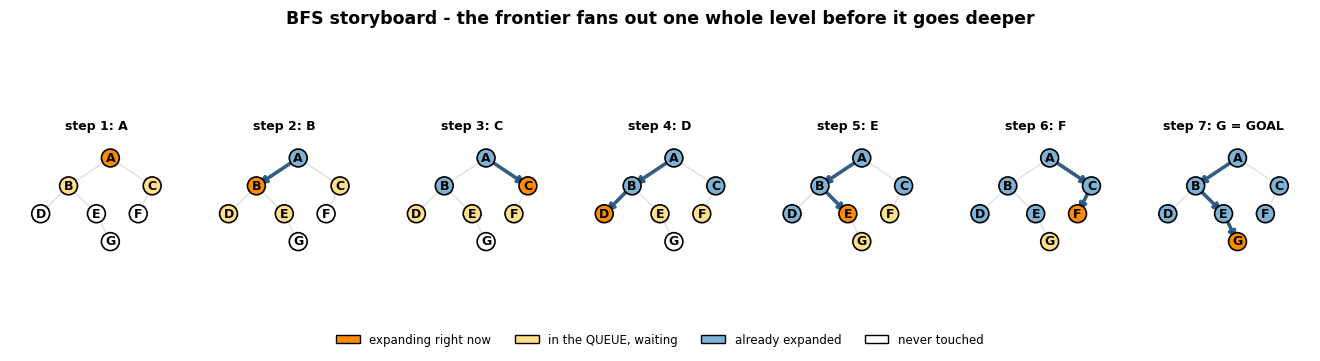

In [5]:
# STORYBOARD: the same BFS run you just read as text, drawn as one panel per step.
# WHAT this cell does: re-runs BFS silently, saving a snapshot of the search state after every
#   step, then draws all the snapshots side by side as a frame grid (a storyboard).
# WHY a grid and not an animation: a row of frames renders identically everywhere, prints on
#   paper, and lets you compare step 2 against step 6 at a glance instead of from memory.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

# Same node coordinates the earlier figures used, so every picture in this notebook lines up.
STORYBOARD_POS = {
    'A': (3, 3), 'B': (1.5, 2), 'C': (4.5, 2),
    'D': (0.5, 1), 'E': (2.5, 1), 'F': (4, 1), 'G': (3, 0)
}
# One colour per role a node can play at a given instant.
COLOR_NOW, COLOR_WAITING = "#ff8c00", "#ffe08a"   # being expanded now / sitting in the frontier
COLOR_DONE, COLOR_UNSEEN = "#7fb3d5", "white"     # already expanded / never touched at all


def draw_search_storyboard(frames, title, path_color, waiting_label):
    """Draw one small graph per recorded step, left to right.

    frames: list of dicts with keys step, now, path, done, waiting, goal.
    Kept deliberately generic so BFS and DFS share ONE drawing routine - if the picture is the
    same picture, any difference you see between the two rows is a difference in the ALGORITHM.
    """
    n_frames = len(frames)
    fig, axes = plt.subplots(1, n_frames, figsize=(1.9 * n_frames, 3.1))
    if n_frames == 1:
        axes = [axes]

    for ax, frame in zip(axes, frames):
        # 1. the whole graph in pale grey, so the unexplored part stays visible
        for node, neighbours in graph.items():
            x1, y1 = STORYBOARD_POS[node]
            for neighbour in neighbours:
                x2, y2 = STORYBOARD_POS[neighbour]
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle='->', color='lightgray', lw=1, alpha=.7))

        # 2. the path that leads to the node being expanded in THIS frame
        path = frame['path']
        for i in range(len(path) - 1):
            x1, y1 = STORYBOARD_POS[path[i]]
            x2, y2 = STORYBOARD_POS[path[i + 1]]
            ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                        arrowprops=dict(arrowstyle='->', color=path_color, lw=2.6, alpha=.9))

        # 3. every node, coloured by the role it plays at this instant
        for node, (x, y) in STORYBOARD_POS.items():
            if node == frame['now']:
                face = COLOR_NOW
            elif node in frame['waiting']:
                face = COLOR_WAITING
            elif node in frame['done']:
                face = COLOR_DONE
            else:
                face = COLOR_UNSEEN
            ax.add_patch(plt.Circle((x, y), .32, facecolor=face, edgecolor='black', lw=1.2, zorder=5))
            ax.text(x, y, node, ha='center', va='center', fontsize=9, fontweight='bold', zorder=6)

        ax.set_xlim(-.6, 5.6)
        ax.set_ylim(-.7, 3.7)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f"step {frame['step']}: {frame['now']}" + (" = GOAL" if frame['goal'] else ""),
                     fontsize=9, fontweight='bold')

    legend = [
        mpatches.Patch(facecolor=COLOR_NOW, edgecolor='k', label='expanding right now'),
        mpatches.Patch(facecolor=COLOR_WAITING, edgecolor='k', label=waiting_label),
        mpatches.Patch(facecolor=COLOR_DONE, edgecolor='k', label='already expanded'),
        mpatches.Patch(facecolor=COLOR_UNSEEN, edgecolor='k', label='never touched'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=4, fontsize=8.5, frameon=False,
               bbox_to_anchor=(.5, -.06))
    fig.suptitle(title, fontsize=12.5, fontweight='bold', y=1.06)
    plt.tight_layout()
    plt.show()


def bfs_snapshots(graph, start, goal):
    """Exactly the BFS above, with the printing replaced by a snapshot of the state."""
    queue = deque([(start, [start])])
    done = set()
    frames = []
    step = 0
    while queue:
        step += 1
        current, path = queue.popleft()
        if current == goal:
            done.add(current)
            frames.append(dict(step=step, now=current, path=path, done=set(done),
                               waiting=[n for n, _ in queue], goal=True))
            break
        if current not in done:
            done.add(current)
            for neighbour in graph.get(current, []):
                if neighbour not in done:
                    queue.append((neighbour, path + [neighbour]))
            frames.append(dict(step=step, now=current, path=path, done=set(done),
                               waiting=[n for n, _ in queue], goal=False))
    return frames


bfs_frames = bfs_snapshots(graph, 'A', 'G')

# The step table under the picture: the same frames as numbers, so nothing is only in the image.
print(f"{'step':>4}  {'expanding':>9}  {'queue after this step':<24}  {'expanded so far':>15}")
print("-" * 62)
for frame in bfs_frames:
    print(f"{frame['step']:>4}  {frame['now']:>9}  {str(frame['waiting']):<24}  {len(frame['done']):>15}")
print(f"\nBFS expanded {len(bfs_frames)} of the {len(graph)} nodes before it stopped.")

draw_search_storyboard(
    bfs_frames,
    "BFS storyboard - the frontier fans out one whole level before it goes deeper",
    path_color="#1f4e79",
    waiting_label="in the QUEUE, waiting",
)


### 🔎 Read the storyboard

**What to look for.** Follow the *yellow* nodes — those are the ones sitting in the queue, waiting.
In **step 1** the yellow set is exactly `{B, C}`: the whole of level 1, and nothing deeper. By
**step 3** the yellow set is exactly `{D, E, F}`: the whole of level 2, and level 1 is finished —
`B` is blue, `C` is orange because it is being expanded at that very moment. BFS never takes a node
at depth 3 out of the queue until every node at depth 2 has been taken out. In the last frame
**every one of the seven circles is coloured** — BFS expanded all of them.

**What it proves.** This picture *is* the "explores level by level, like ripples in a pond" sentence
from the Part 2 story, and it is also the reason BFS returns the shortest path in edges: it cannot
return a 4-step path before it has finished checking every 3-step one, because those 3-step ones were
all in the queue ahead of it.

**The cost, visible in the same picture.** Count the yellow circles at step 3 — three nodes held in
memory at once on a seven-node toy graph. The queue is *widest* exactly when the search is deepest.
Keep that image; Part 7 measures what it costs on a graph that is not a toy.

## Part 3: Depth-First Search (DFS)

### 📚 Prerequisites (What You Need First)
- ✅ **BFS** (from Part 2) - Understanding search algorithms
- ✅ **Graph representation** (from Part 1) - Understanding graphs
- ✅ **Recursion** - Understanding recursive functions

### 🔗 Relationship: What This Builds On
This comes **AFTER** BFS - we compare different exploration strategies!
- Builds on: BFS concepts (queue, visited tracking)
- Comes BEFORE: A* (which combines BFS/DFS ideas)
- Alternative to: BFS (different strategy, same goal)

### 📖 The Story
DFS goes DEEP first, like exploring a cave system. It goes as far as possible before backtracking.

**Before DFS**: We explored level by level (BFS).
**After DFS**: We'll see a completely different exploration pattern - going deep first!

In [6]:
# Implement Depth-First Search (DFS) using recursion, with a printed trace.
# Why: contrast with BFS - DFS dives down one branch and backtracks, so it can find a longer path first.

def dfs_with_visualization(graph, start, goal, visited=None, path=None, exploration_order=None):
    """
    Depth-First Search (Recursive) with step-by-step visualization.
    
    HOW IT WORKS:
    1. Start at a node
    2. Go as DEEP as possible along one path
    3. When you hit a dead end, backtrack and try another path
    4. Continue until goal is found
    
    This uses a STACK (Last In First Out) - implemented via recursion!
    """
    # Initialize on first call
    if visited is None:
        visited = set()
        exploration_order = []
        print(f"🔍 Starting DFS from {start} to {goal}...")
        print(f"📋 Strategy: Go DEEP first, backtrack when needed\n")
    
    if path is None:
        path = []
    
    # Mark current node as visited
    visited.add(start)
    exploration_order.append(start)
    path = path + [start]  # Add current node to path
    
    print(f"📍 At node '{start}' | Path: {' -> '.join(path)} | Visited: {sorted(visited)}")
    
    # Check if we found the goal!
    if start == goal:
        print(f"\n🎉 SUCCESS! Found goal '{goal}'!")
        print(f"✅ Final path: {' -> '.join(path)}")
        return path, exploration_order
    
    # Explore neighbors - go DEEP first (take first available neighbor)
    neighbors = graph.get(start, [])
    for neighbor in neighbors:
        if neighbor not in visited:
            print(f"   Going deeper to '{neighbor}'...")
            # Recursively explore this neighbor (going deeper)
            result = dfs_with_visualization(graph, neighbor, goal, visited, path, exploration_order)
            if result and result[0]:  # If we found a path (result[0] is not None), return it
                return result
            else:
                print(f"   Backtracking from '{neighbor}' (no path found)")
    
    # No path found from this node
    return None, exploration_order

# Run DFS
print("=" * 60)
dfs_path, dfs_order = dfs_with_visualization(graph, 'A', 'G')
if dfs_path:
    print(f"\n📈 DFS Exploration order: {' -> '.join(dfs_order)}")
    print(f"📊 Path length: {len(dfs_path) - 1} steps")
else:
    print("❌ Goal not found with DFS!")

🔍 Starting DFS from A to G...
📋 Strategy: Go DEEP first, backtrack when needed

📍 At node 'A' | Path: A | Visited: ['A']
   Going deeper to 'B'...
📍 At node 'B' | Path: A -> B | Visited: ['A', 'B']
   Going deeper to 'D'...
📍 At node 'D' | Path: A -> B -> D | Visited: ['A', 'B', 'D']
   Backtracking from 'D' (no path found)
   Going deeper to 'E'...
📍 At node 'E' | Path: A -> B -> E | Visited: ['A', 'B', 'D', 'E']
   Going deeper to 'G'...
📍 At node 'G' | Path: A -> B -> E -> G | Visited: ['A', 'B', 'D', 'E', 'G']

🎉 SUCCESS! Found goal 'G'!
✅ Final path: A -> B -> E -> G

📈 DFS Exploration order: A -> B -> D -> E -> G
📊 Path length: 3 steps


step  entering  recursion stack (the path)    depth
--------------------------------------------------------
   1         A  A                                 1
   2         B  A -> B                            2
   3         D  A -> B -> D                       3
   4         E  A -> B -> E                       3
   5         G  A -> B -> E -> G                  4

DFS expanded 5 nodes; BFS expanded 7.
Nodes DFS never even looked at: ['C', 'F']


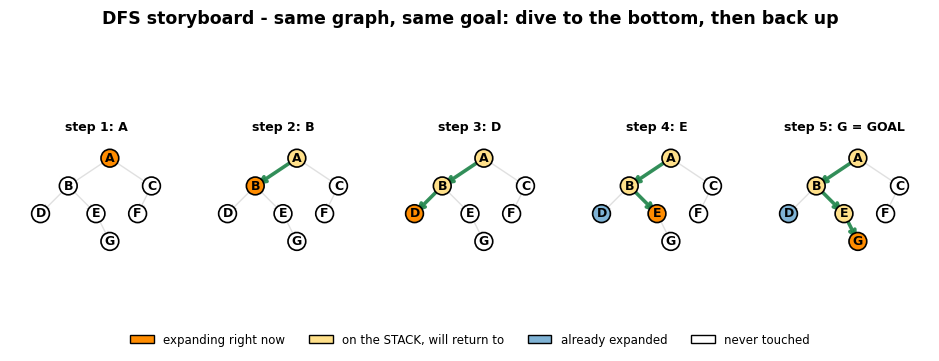

In [7]:
# STORYBOARD: the same DFS run, drawn with the SAME routine used for BFS above.
# WHAT this cell does: re-runs DFS silently, records one snapshot per node it enters, and hands
#   the snapshots to draw_search_storyboard - identical layout, identical colours, identical scale.
# WHY reuse the drawing code: when the picture is held constant, every visible difference between
#   this row and the BFS row is a difference in the ALGORITHM, not in how it was drawn.


def dfs_snapshots(graph, start, goal, done=None, path=None, frames=None):
    """Exactly the DFS above, with the printing replaced by a snapshot of the state.

    'waiting' here is the recursion STACK - the ancestors we will return to if this branch
    fails. That is DFS's frontier, and it is what the yellow circles show.
    """
    if done is None:
        done, frames = set(), []
    path = (path or []) + [start]
    done.add(start)
    frames.append(dict(step=len(frames) + 1, now=start, path=list(path), done=set(done),
                       waiting=list(path[:-1]), goal=(start == goal)))
    if start == goal:
        return True, frames
    for neighbour in graph.get(start, []):
        if neighbour not in done:
            found, frames = dfs_snapshots(graph, neighbour, goal, done, path, frames)
            if found:
                return True, frames
    return False, frames


_, dfs_frames = dfs_snapshots(graph, 'A', 'G')

print(f"{'step':>4}  {'entering':>8}  {'recursion stack (the path)':<28}  {'depth':>5}")
print("-" * 56)
for frame in dfs_frames:
    print(f"{frame['step']:>4}  {frame['now']:>8}  {' -> '.join(frame['path']):<28}  {len(frame['path']):>5}")

# The single number the two storyboards are really about.
untouched = sorted(set(graph) - dfs_frames[-1]['done'])
print(f"\nDFS expanded {len(dfs_frames)} nodes; BFS expanded {len(bfs_frames)}.")
print(f"Nodes DFS never even looked at: {untouched if untouched else 'none'}")

draw_search_storyboard(
    dfs_frames,
    "DFS storyboard - same graph, same goal: dive to the bottom, then back up",
    path_color="#1e8449",
    waiting_label="on the STACK, will return to",
)


### 🔎 Read the storyboard — and compare it with the one above

**What to look for, frame by frame.** By **step 3** DFS is already at `D`, the deepest point of the
left branch — while `C` and the whole right branch are still **white**, untouched. BFS had coloured
`C` back at its step 3. Then watch the transition from **step 3 to step 4**: `D` turns blue (a dead
end, finished) and the green stack lets go of `D` and re-grows through `E`. *That single colour change
is backtracking* — there is no other picture of it.

**The punchline is in the last frame of each row.** BFS's final frame has all seven circles coloured.
DFS's final frame still has **`C` and `F` white** — it found the goal without ever looking at them.
That is precisely the `7` versus `5` in the "Nodes Explored" column of the comparison table further
down: not a number to memorise, a picture to remember.

**What it proves, and what it does not.** DFS did less work *here*, and both algorithms happened to
return a 3-step path. That is luck, not a guarantee: DFS commits to the first branch it can reach and
returns the first path it finds, whatever its length. The maze at the end of this notebook is the same
comparison with the luck removed — there, DFS's answer is two steps longer than BFS's.

## Part 4: A* Search Algorithm

### 📚 Prerequisites (What You Need First)
- ✅ **BFS** (from Part 2) - Understanding queue-based search
- ✅ **DFS** (from Part 3) - Understanding search strategies
- ✅ **Priority queues** - Understanding heapq (for smart ordering)

### 🔗 Relationship: What This Builds On
This is an **ADVANCED** algorithm that combines ideas from BFS and DFS!
- Builds on: BFS (queue structure) + DFS (goal-oriented thinking)
- Builds on: Heuristic functions (smart guessing)
- Comes BEFORE: Dijkstra (which extends A* concepts)
- More advanced than: BFS, DFS (adds intelligence)

### 📖 The Story
A* is SMART! It uses a "heuristic" (educated guess) about distance to goal to explore more promising paths first.

**Before A***: We explored blindly (BFS) or deeply (DFS).
**After A***: We use intelligence to guide our search - like using a compass in a maze!

In [8]:
# Implement A* search: like BFS/Dijkstra but guided by a heuristic estimate of the remaining distance.
# Why: the heuristic lets A* skip unpromising branches - this is what makes GPS-style routing fast.

def heuristic(node, goal):
    """
    Heuristic function: estimates distance from node to goal.
    This is our "educated guess" - helps A* make smart decisions.
    
    In this simple case, we use alphabetical distance.
    In real applications (like maps), this would be actual distance.
    """
    # Simple heuristic: how many letters away?
    return abs(ord(node) - ord(goal)) if isinstance(node, str) else 0

def astar_with_visualization(graph, start, goal, edge_costs=None):
    """
    A* Search Algorithm with step-by-step visualization.
    
    HOW IT WORKS:
    A* uses f(n) = g(n) + h(n) where:
    - g(n): actual cost from start to node n (known)
    - h(n): estimated cost from node n to goal (heuristic)
    - f(n): total estimated cost (priority)
    
    We explore nodes with LOWEST f(n) first - this guides us toward the goal!
    """
    if edge_costs is None:
        edge_costs = {}
    
    # Priority queue: (f_score, g_score, current_node, path)
    # heapq maintains items in priority order (smallest first)
    # Seed with f(start) = g(start) + h(start) = 0 + h(start), so the printed
    # trace obeys the defining formula f = g + h from the very first node
    open_set = [(heuristic(start, goal), 0, start, [start])]
    visited = set()
    g_scores = {start: 0}  # Actual cost from start to each node
    exploration_order = []
    
    print(f"🔍 Starting A* from {start} to {goal}...")
    print(f"📋 Strategy: Use heuristic to guide search intelligently\n")
    
    step = 0
    while open_set:
        step += 1
        # Get node with LOWEST f_score (highest priority)
        f_score, g_score, current, path = heapq.heappop(open_set)
        
        # Get heuristic value for this node
        h_value = heuristic(current, goal)
        
        print(f"Step {step}: Processing '{current}'")
        print(f"   Path: {' -> '.join(path)}")
        print(f"   g({current}) = {g_score} (actual cost from start)")
        print(f"   h({current}) = {h_value} (estimated cost to goal)")
        print(f"   f({current}) = {f_score} (total: g + h)")
        
        if current == goal:
            print(f"\n🎉 SUCCESS! Found goal '{goal}'!")
            print(f"✅ Final path: {' -> '.join(path)}")
            print(f"📊 Path length: {len(path) - 1} steps")
            print(f"💰 Total cost: {g_score}")
            exploration_order.append(current)
            return path, g_score, exploration_order
        
        if current in visited:
            continue
        
        visited.add(current)
        exploration_order.append(current)
        
        # Explore neighbors
        neighbors = graph.get(current, [])
        print(f"   Exploring neighbors: {neighbors}")
        
        for neighbor in neighbors:
            if neighbor in visited:
                continue
            
            # Calculate edge cost (default 1 if not specified)
            edge_key = (current, neighbor)
            edge_cost = edge_costs.get(edge_key, 1)
            
            # Calculate actual cost to reach neighbor
            tentative_g = g_score + edge_cost
            
            # Only update if this is a better path
            if neighbor not in g_scores or tentative_g < g_scores[neighbor]:
                g_scores[neighbor] = tentative_g
                h_score = heuristic(neighbor, goal)  # Heuristic: estimated distance to goal
                f_score = tentative_g + h_score  # Total estimated cost
                
                print(f"      '{neighbor}': g={tentative_g}, h={h_score}, f={f_score} -> Added to queue")
                # Add to priority queue
                heapq.heappush(open_set, (f_score, tentative_g, neighbor, path + [neighbor]))
        
        print()
    
    return None, float('inf'), exploration_order

# Run A*
print("=" * 60)
astar_path, astar_cost, astar_order = astar_with_visualization(graph, 'A', 'G')
if astar_path:
    print(f"\n📈 A* Exploration order: {' -> '.join(astar_order)}")

🔍 Starting A* from A to G...
📋 Strategy: Use heuristic to guide search intelligently

Step 1: Processing 'A'
   Path: A
   g(A) = 0 (actual cost from start)
   h(A) = 6 (estimated cost to goal)
   f(A) = 6 (total: g + h)
   Exploring neighbors: ['B', 'C']
      'B': g=1, h=5, f=6 -> Added to queue
      'C': g=1, h=4, f=5 -> Added to queue

Step 2: Processing 'C'
   Path: A -> C
   g(C) = 1 (actual cost from start)
   h(C) = 4 (estimated cost to goal)
   f(C) = 5 (total: g + h)
   Exploring neighbors: ['F']
      'F': g=2, h=1, f=3 -> Added to queue

Step 3: Processing 'F'
   Path: A -> C -> F
   g(F) = 2 (actual cost from start)
   h(F) = 1 (estimated cost to goal)
   f(F) = 3 (total: g + h)
   Exploring neighbors: []

Step 4: Processing 'B'
   Path: A -> B
   g(B) = 1 (actual cost from start)
   h(B) = 5 (estimated cost to goal)
   f(B) = 6 (total: g + h)
   Exploring neighbors: ['D', 'E']
      'D': g=2, h=3, f=5 -> Added to queue
      'E': g=2, h=2, f=4 -> Added to queue

Step 5: 

Order in which A* popped nodes (lowest f first):
   #1  A   f=6  (g=0 + h=6)
   #2  C   f=5  (g=1 + h=4)
   #3  F   f=3  (g=2 + h=1)
   #4  B   f=6  (g=1 + h=5)
   #5  E   f=4  (g=2 + h=2)
   #6  G   f=3  (g=3 + h=0)

Is the heuristic admissible? h(n) must never exceed the TRUE remaining cost h*(n):
   A: h=6, h*=3  ->  OVERESTIMATES by 3
   B: h=5, h*=2  ->  OVERESTIMATES by 3
   C: h=4, h*=unreachable (no path to G at all)
   D: h=3, h*=unreachable (no path to G at all)
   E: h=2, h*=1  ->  OVERESTIMATES by 1
   F: h=1, h*=unreachable (no path to G at all)
   G: h=0, h*=0  ->  OK


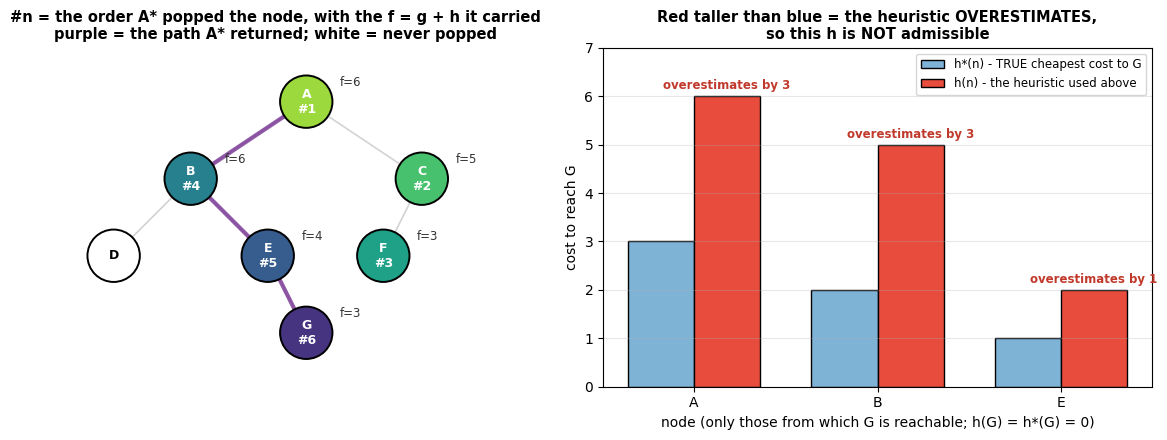

In [9]:
# FIGURE: two questions about the A* run above that the printed trace cannot answer.
#   LEFT  - in what ORDER did A* pop nodes, and what f = g + h did each one carry?
#   RIGHT - is this heuristic actually admissible? (i.e. does h ever overestimate?)
# WHY: A* is only guaranteed to return the shortest path when h NEVER overestimates the true
#   remaining cost. That guarantee is a comparison between two numbers per node - so plot both.
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


def true_remaining_cost(graph, source, goal):
    """The real cheapest cost from `source` to `goal`, found by BFS (all edges cost 1).

    This is h*(n), the quantity the heuristic h(n) is supposed to under-estimate.
    Returns None when the goal simply cannot be reached from `source`.
    """
    queue = deque([(source, 0)])
    seen = {source}
    while queue:
        node, distance = queue.popleft()
        if node == goal:
            return distance
        for neighbour in graph.get(node, []):
            if neighbour not in seen:
                seen.add(neighbour)
                queue.append((neighbour, distance + 1))
    return None


def astar_pop_order(graph, start, goal):
    """Same A* as above, recording (node, f, g) each time a node is POPPED."""
    open_set = [(heuristic(start, goal), 0, start, [start])]
    seen, g_scores, pops = set(), {start: 0}, []
    while open_set:
        f_score, g_score, current, path = heapq.heappop(open_set)
        if current == goal:
            pops.append((current, f_score, g_score))
            return pops, path
        if current in seen:
            continue
        seen.add(current)
        pops.append((current, f_score, g_score))
        for neighbour in graph.get(current, []):
            if neighbour in seen:
                continue
            tentative_g = g_score + 1
            if neighbour not in g_scores or tentative_g < g_scores[neighbour]:
                g_scores[neighbour] = tentative_g
                heapq.heappush(open_set, (tentative_g + heuristic(neighbour, goal),
                                          tentative_g, neighbour, path + [neighbour]))
    return pops, None


pops, astar_path_again = astar_pop_order(graph, 'A', 'G')
pop_rank = {node: i + 1 for i, (node, _, _) in enumerate(pops)}
pop_f = {node: f for node, f, _ in pops}

print("Order in which A* popped nodes (lowest f first):")
for node, f_score, g_score in pops:
    print(f"   #{pop_rank[node]}  {node}   f={f_score}  (g={g_score} + h={heuristic(node, 'G')})")

print("\nIs the heuristic admissible? h(n) must never exceed the TRUE remaining cost h*(n):")
for node in sorted(graph):
    h_star = true_remaining_cost(graph, node, 'G')
    h_value = heuristic(node, 'G')
    if h_star is None:
        print(f"   {node}: h={h_value}, h*=unreachable (no path to G at all)")
    else:
        verdict = "OK" if h_value <= h_star else f"OVERESTIMATES by {h_value - h_star}"
        print(f"   {node}: h={h_value}, h*={h_star}  ->  {verdict}")

fig, (ax_order, ax_admiss) = plt.subplots(1, 2, figsize=(12, 4.5))

# LEFT PANEL: the graph, each popped node stamped with its position in the pop order.
for node, neighbours in graph.items():
    x1, y1 = STORYBOARD_POS[node]
    for neighbour in neighbours:
        x2, y2 = STORYBOARD_POS[neighbour]
        ax_order.annotate('', xy=(x2, y2), xytext=(x1, y1),
                          arrowprops=dict(arrowstyle='->', color='lightgray', lw=1.2))
for i in range(len(astar_path_again) - 1):
    x1, y1 = STORYBOARD_POS[astar_path_again[i]]
    x2, y2 = STORYBOARD_POS[astar_path_again[i + 1]]
    ax_order.annotate('', xy=(x2, y2), xytext=(x1, y1),
                      arrowprops=dict(arrowstyle='->', color='#7d3c98', lw=3, alpha=.85))
for node, (x, y) in STORYBOARD_POS.items():
    if node in pop_rank:  # darker = popped later
        face = plt.cm.viridis_r(.15 + .7 * (pop_rank[node] - 1) / max(len(pop_rank) - 1, 1))
        label, text_color = f"{node}\n#{pop_rank[node]}", 'white'
    else:
        face, label, text_color = 'white', node, 'black'
    ax_order.add_patch(plt.Circle((x, y), .34, facecolor=face, edgecolor='black', lw=1.4, zorder=5))
    ax_order.text(x, y, label, ha='center', va='center', fontsize=9, fontweight='bold',
                  color=text_color, zorder=6)
    if node in pop_f:
        ax_order.text(x + .44, y + .20, f"f={pop_f[node]}", fontsize=8.5, color='#333')
ax_order.set_xlim(-.8, 6.0)
ax_order.set_ylim(-.7, 3.7)
ax_order.set_aspect('equal')
ax_order.axis('off')
ax_order.set_title("#n = the order A* popped the node, with the f = g + h it carried\n"
                   "purple = the path A* returned; white = never popped",
                   fontsize=10.5, fontweight='bold')

# RIGHT PANEL: h(n) against h*(n), for the nodes from which G is actually reachable.
reachable = [n for n in sorted(graph) if true_remaining_cost(graph, n, 'G') not in (None, 0)]
x_positions = np.arange(len(reachable))
bar_width = .36
true_costs = [true_remaining_cost(graph, n, 'G') for n in reachable]
heuristics = [heuristic(n, 'G') for n in reachable]
ax_admiss.bar(x_positions - bar_width / 2, true_costs, bar_width, color="#7fb3d5",
              edgecolor='black', label="h*(n) - TRUE cheapest cost to G")
ax_admiss.bar(x_positions + bar_width / 2, heuristics, bar_width, color="#e74c3c",
              edgecolor='black', label="h(n) - the heuristic used above")
for i, (true_cost, guess) in enumerate(zip(true_costs, heuristics)):
    if guess > true_cost:
        ax_admiss.annotate(f"overestimates by {guess - true_cost}",
                           xy=(i + bar_width / 2, guess), xytext=(0, 5),
                           textcoords='offset points', ha='center', fontsize=8.5,
                           color='#c0392b', fontweight='bold')
ax_admiss.set_xticks(x_positions)
ax_admiss.set_xticklabels(reachable)
ax_admiss.set_xlabel("node (only those from which G is reachable; h(G) = h*(G) = 0)")
ax_admiss.set_ylabel("cost to reach G")
ax_admiss.set_ylim(0, max(heuristics) + 1)
ax_admiss.set_title("Red taller than blue = the heuristic OVERESTIMATES,\nso this h is NOT admissible",
                    fontsize=10.5, fontweight='bold')
ax_admiss.legend(fontsize=8.5, loc='upper right')
ax_admiss.grid(axis='y', alpha=.3)
plt.tight_layout()
plt.show()


### 🔎 Read the figure — this one is uncomfortable, and that is the point

**Left panel: the heuristic sent A\* down a dead end first.** Read the `#` stamps in order:
`A(#1) → C(#2) → F(#3) → B(#4) → E(#5) → G(#6)`. After expanding `A`, both `B` and `C` were in the
open set, and A\* chose `C` because `f(C) = 5` beat `f(B) = 6` — you can read both numbers off the
picture. But `C`'s branch ends at `F`, a dead end. The "intelligent" algorithm spent two of its six
expansions on the branch that goes nowhere, and only then returned to `B`, which is where the answer
was. `D` stayed white: it was pushed into the open set but the goal was found before it was ever
popped.

**Right panel: why that happened.** For every node from which `G` can actually be reached, the red
bar is taller than the blue one. `h(A) = 6` while the true remaining cost is `3`. This heuristic
(`|ord(node) − ord(goal)|`) is a stand-in for distance that has nothing to do with the graph, and it
overestimates everywhere. That breaks *admissibility* — and admissibility is the exact condition Hart,
Nilsson and Raphael needed to prove A\* optimal (see 📚 References).

**What it proves.** A\* returned `A → B → E → G`, which *is* the shortest path. It got there anyway.
That is the trap: an inadmissible heuristic gives you no error, no warning, and often a correct-looking
answer — until the one graph where it quietly returns a longer path. When the ⚠️ section below says
"A\* is optimal only if the heuristic never overestimates", this red-versus-blue chart is what that
sentence looks like. On a real map, straight-line distance is the safe default precisely because no
road can ever be shorter than the straight line, so `h ≤ h*` is guaranteed by geometry rather than
hoped for.

## Part 4.5: Dijkstra's Algorithm

### 📚 Prerequisites (What You Need First)
- ✅ **BFS** (from Part 2) - Understanding queue-based search
- ✅ **A*** (from Part 4) - Understanding weighted graphs and priority queues
- ✅ **Graph representation** (from Part 1) - Understanding graphs with weights

### 🔗 Relationship: What This Builds On
This comes **AFTER** A* - it's A* without a heuristic!
- Builds on: Priority queue concepts from A*
- Alternative to: A* (when no good heuristic available)
- Best for: Weighted graphs without heuristic information

### 📖 The Story
Dijkstra's algorithm finds the shortest path in weighted graphs. It's like A* but doesn't need a heuristic - it explores all possibilities systematically!

**Before Dijkstra**: We need a heuristic for A*, but sometimes we don't have one.
**After Dijkstra**: We can find optimal paths in weighted graphs without heuristics!

In [10]:
# Dijkstra's Algorithm: Finding Shortest Path in Weighted Graphs
# ⏰ WHEN to use: Weighted graphs without heuristic - guarantees optimal path!
# 💡 WHY use: Finds shortest path by cost (not steps) - more realistic than BFS!

import heapq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def dijkstra_with_visualization(graph, start, goal, edge_costs=None):
    """
    Dijkstra's Algorithm with step-by-step visualization.
    
    ⏰ WHEN to use: Weighted graphs - when edges have different costs/weights
    💡 WHY use: Guarantees shortest path by total cost (optimal solution!)
    
    HOW IT WORKS:
    Dijkstra's is like BFS but considers edge weights (costs):
    1. Use priority queue (like A*) but WITHOUT heuristic
    2. Priority = distance from start (cost so far)
    3. Always explore closest unvisited node first
    4. Guarantees shortest path by total cost!
    
    Key difference from A*:
    - A* uses: f(n) = g(n) + h(n) [actual cost + heuristic]
    - Dijkstra uses: f(n) = g(n) [just actual cost, no heuristic!]
    """
    if edge_costs is None:  # Check if edge costs provided: If None, use default cost of 1 for all edges
        edge_costs = {}  # Initialize empty dict: Will use default cost of 1 if edge not in dict
    
    # Priority queue: (distance_from_start, current_node, path)
    # ⏰ WHEN to use: Priority queue for weighted graphs - need to explore cheapest path first!
    # 💡 WHY use: heapq maintains items sorted by distance - always get closest node next!
    open_set = [(0, start, [start])]  # Initialize queue: Start node with distance 0, empty path
    visited = set()  # Track visited nodes: Set for O(1) membership checks (fast!)
    distances = {start: 0}  # Track shortest distances: Dictionary stores best distance to each node
    exploration_order = []  # Track exploration: List to remember order we visited nodes (for visualization)
    
    print(f"🔍 Starting Dijkstra's from {start} to {goal}...")
    print(f"📋 Strategy: Explore closest unvisited node first (guaranteed optimal path!)\n")
    
    step = 0  # Step counter: Track which iteration we're on
    while open_set:  # Main loop: Continue while queue has nodes to explore
        step += 1  # Increment step: Count this iteration
        
        # Get node with SMALLEST distance (highest priority = smallest distance!)
        # ⏰ WHEN to use: heapq.heappop gets smallest item - closest node first!
        # 💡 WHY use: Always explore closest node first = guarantees optimal path!
        distance, current, path = heapq.heappop(open_set)  # Pop smallest: Get node with smallest distance from start
        
        print(f"Step {step}: Processing '{current}'")
        print(f"   Path: {' -> '.join(path)}")  # Show path: Display path taken to reach current node
        print(f"   Distance from start: {distance}")  # Show distance: Display total cost from start to current
        
        # Check if we found the goal!
        if current == goal:  # Goal check: Did we reach the target node?
            print(f"\n🎉 SUCCESS! Found goal '{goal}'!")
            print(f"✅ Final path: {' -> '.join(path)}")
            print(f"📊 Path length: {len(path) - 1} steps")
            print(f"💰 Total cost: {distance}")  # Show total cost: Display shortest path cost (optimal!)
            exploration_order.append(current)  # Add to exploration: Include goal in exploration order
            return path, distance, exploration_order  # Return solution: Return path, cost, and exploration order
        
        # Skip if already visited (we already found shortest path to this node)
        if current in visited:  # Check if visited: If already processed, skip (already have optimal path!)
            continue  # Skip node: Continue to next iteration (this node already processed)
        
        visited.add(current)  # Mark as visited: Add current node to visited set (found optimal path to it!)
        exploration_order.append(current)  # Track exploration: Add current node to exploration order
        
        # Explore neighbors
        neighbors = graph.get(current, [])  # Get neighbors: Get list of nodes connected to current node
        print(f"   Exploring neighbors: {neighbors}")
        
        for neighbor in neighbors:  # Loop through neighbors: Iterate over each neighbor
            if neighbor in visited:  # Check if visited: Skip neighbors we've already processed
                continue  # Skip visited: Continue to next neighbor
            
            # Calculate edge cost (cost to travel from current to neighbor)
            edge_key = (current, neighbor)  # Create edge key: Tuple (from_node, to_node) for dictionary lookup
            edge_cost = edge_costs.get(edge_key, 1)  # Get edge cost: Look up cost in dict, default to 1 if not specified
            
            # Calculate total distance to reach neighbor via current path
            tentative_distance = distance + edge_cost  # Calculate new distance: Current distance + edge cost = new total distance
            
            # Only update if this is a SHORTER path to neighbor
            # ⏰ WHEN to use: Check if new path is better - only update if shorter!
            # 💡 WHY use: Ensures we always have shortest path to each node (optimality!)
            if neighbor not in distances or tentative_distance < distances[neighbor]:  # Check if better: If neighbor not seen OR new path is shorter
                distances[neighbor] = tentative_distance  # Update distance: Store shortest distance to neighbor
                print(f"      '{neighbor}': distance={tentative_distance} (via {current}) -> Added to queue")  # Show update: Display new/better path found
                # Add to priority queue with distance as priority
                heapq.heappush(open_set, (tentative_distance, neighbor, path + [neighbor]))  # Add to queue: Push neighbor with distance as priority (smallest first!)
            else:
                print(f"      '{neighbor}': distance={tentative_distance} (via {current}) -> Skip (already have shorter path: {distances[neighbor]})")  # Show skip: Display why we skip this path
        
        print()
    
    return None, float('inf'), exploration_order  # No path found: Return None, infinite distance, and exploration order

# Create weighted graph (edges have different costs)
print("=" * 70)
print("✅ AFTER: Dijkstra's Algorithm (Weighted Graphs)")
print("=" * 70)
print()

# Same graph structure but with edge costs (weights)
weighted_graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['E', 'F'],
    'D': ['G'],
    'E': ['G'],
    'F': ['G'],
    'G': []
}

# Define edge costs (weights) - different costs for different edges!
# ⏰ WHEN to use: Edge costs represent real-world distances, time, or costs
# 💡 WHY use: Different edges have different costs - Dijkstra finds cheapest path!
edge_costs = {
    ('A', 'B'): 3,  # Path A->B costs 3
    ('A', 'C'): 5,  # Path A->C costs 5
    ('B', 'D'): 2,  # Path B->D costs 2
    ('B', 'E'): 6,  # Path B->E costs 6
    ('C', 'E'): 3,  # Path C->E costs 3
    ('C', 'F'): 4,  # Path C->F costs 4
    ('D', 'G'): 1,  # Path D->G costs 1
    ('E', 'G'): 2,  # Path E->G costs 2
    ('F', 'G'): 5   # Path F->G costs 5
}

print("📊 Graph with Edge Costs (Weights):")
print("   A --3--> B --2--> D --1--> G")
print("   |        |                  ^")
print("   5        6                  |")
print("   |        |                  2")
print("   C --3--> E ------------------")
print("   |        |")
print("   4        5")
print("   |        |")
print("   F ------->")
print()
print("💡 Key: Numbers on edges = cost to travel that edge")
print("   Dijkstra finds path with LOWEST TOTAL COST!")
print()

# Run Dijkstra's algorithm
dijkstra_path, dijkstra_cost, dijkstra_order = dijkstra_with_visualization(
    weighted_graph, 'A', 'G', edge_costs
)

if dijkstra_path:
    print(f"\n📈 Dijkstra Exploration order: {' -> '.join(dijkstra_order)}")
    print(f"\n🔗 HOW THIS SOLVES THE PROBLEM:")
    print("   ❌ BEFORE: BFS finds shortest by steps (A->B->D->G = 3 steps)")
    print(f"   ✅ AFTER: Dijkstra finds shortest by COST (cost = {dijkstra_cost})")
    print("   • BFS path A->B->D->G costs: 3+2+1 = 6")
    print(f"   • Dijkstra found optimal path with cost: {dijkstra_cost}")
    print("   • Works for weighted graphs (real-world distances/costs)!")
    print("   • Guaranteed optimal (shortest cost path)!")


✅ AFTER: Dijkstra's Algorithm (Weighted Graphs)

📊 Graph with Edge Costs (Weights):
   A --3--> B --2--> D --1--> G
   |        |                  ^
   5        6                  |
   |        |                  2
   C --3--> E ------------------
   |        |
   4        5
   |        |
   F ------->

💡 Key: Numbers on edges = cost to travel that edge
   Dijkstra finds path with LOWEST TOTAL COST!

🔍 Starting Dijkstra's from A to G...
📋 Strategy: Explore closest unvisited node first (guaranteed optimal path!)

Step 1: Processing 'A'
   Path: A
   Distance from start: 0
   Exploring neighbors: ['B', 'C']
      'B': distance=3 (via A) -> Added to queue
      'C': distance=5 (via A) -> Added to queue

Step 2: Processing 'B'
   Path: A -> B
   Distance from start: 3
   Exploring neighbors: ['D', 'E']
      'D': distance=5 (via B) -> Added to queue
      'E': distance=9 (via B) -> Added to queue

Step 3: Processing 'C'
   Path: A -> C
   Distance from start: 5
   Exploring neighbors: ['E'

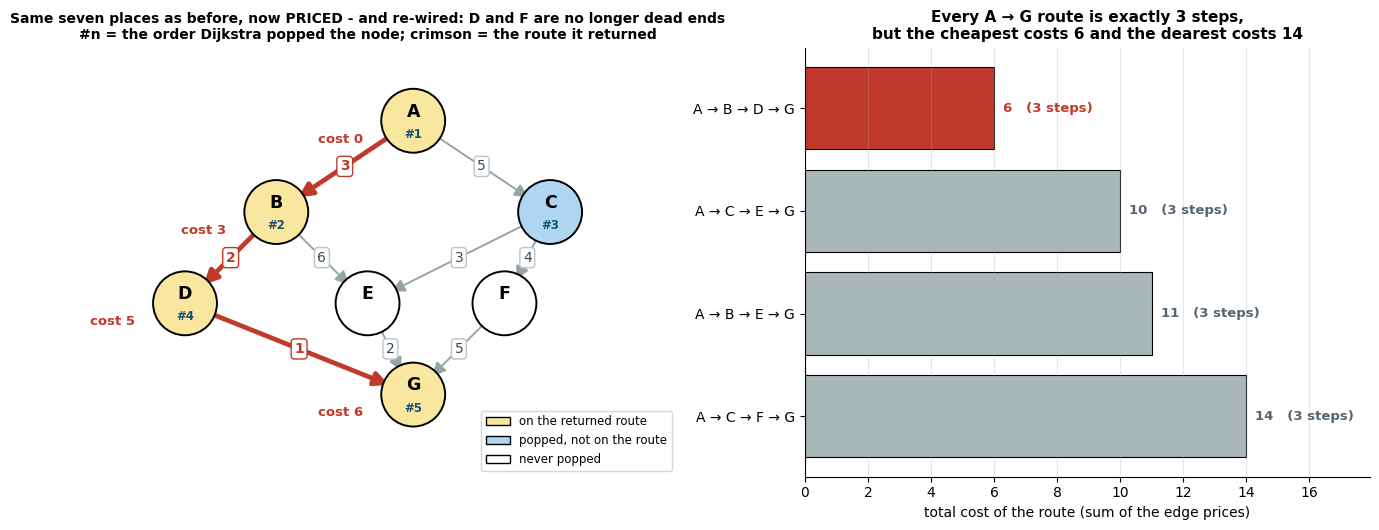


route                   steps  total cost
-----------------------------------------
A -> B -> D -> G            3           6   <- Dijkstra returned this
A -> C -> E -> G            3          10
A -> B -> E -> G            3          11
A -> C -> F -> G            3          14

All 4 routes have the same number of steps (3), so counting steps cannot choose between them.
Costs range from 6 to 14 - a factor of 2.3 between the best and worst 3-step answer.


In [11]:
# FIGURE: what the printed trace above cannot show - the map with its prices on it.
# WHAT this cell does: LEFT, the weighted map with every edge cost written on it, the route
#   Dijkstra returned in crimson, the pop order stamped as #1..#5, and the running total at each
#   node on that route. RIGHT, the total cost of EVERY route from A to G, enumerated by hand.
# WHY the right panel exists: this map is built so that all four A->G routes are exactly 3 edges
#   long. Counting steps therefore cannot separate them at all - only the prices can, and the bar
#   chart is the proof of that sentence rather than the assertion of it.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DIJKSTRA_POS = {  # the same coordinates every other figure in this notebook uses
    'A': (3, 3), 'B': (1.5, 2), 'C': (4.5, 2),
    'D': (0.5, 1), 'E': (2.5, 1), 'F': (4, 1), 'G': (3, 0)
}


def all_routes(graph, start, goal, costs):
    """Enumerate every simple route start->goal and price it. Tiny graph, so brute force is honest."""
    found = []

    def walk(node, route, total):
        if node == goal:
            found.append((route, total))
            return
        for nxt in graph.get(node, []):
            if nxt not in route:
                walk(nxt, route + [nxt], total + costs.get((node, nxt), 1))

    walk(start, [start], 0)
    return sorted(found, key=lambda rt: rt[1])


routes = all_routes(weighted_graph, 'A', 'G', edge_costs)
pop_rank = {node: i + 1 for i, node in enumerate(dijkstra_order)}   # #1, #2, ... = order popped
running = {}                                                        # cost so far along the answer
total_so_far = 0
for i, node in enumerate(dijkstra_path):
    if i:
        total_so_far += edge_costs.get((dijkstra_path[i - 1], node), 1)
    running[node] = total_so_far

fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={'width_ratios': [1.1, 1]})

# ---- LEFT: the weighted map -------------------------------------------------------------
path_edges = {(dijkstra_path[i], dijkstra_path[i + 1]) for i in range(len(dijkstra_path) - 1)}
for node, neighbours in weighted_graph.items():
    x1, y1 = DIJKSTRA_POS[node]
    for neighbour in neighbours:
        x2, y2 = DIJKSTRA_POS[neighbour]
        on_path = (node, neighbour) in path_edges
        # shrinkA/shrinkB stop the arrow at the rim of the circle so the ARROWHEAD is visible.
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1), zorder=3 if on_path else 2,
                    arrowprops=dict(arrowstyle='-|>',
                                    color="#c0392b" if on_path else "#95a5a6",
                                    lw=3.4 if on_path else 1.4, mutation_scale=20, shrinkA=19, shrinkB=19))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(edge_costs.get((node, neighbour), 1)),
                fontsize=10, ha='center', va='center', zorder=4,
                fontweight='bold' if on_path else 'normal',
                color="#c0392b" if on_path else "#34495e",
                bbox=dict(boxstyle='round,pad=0.22', facecolor='white',
                          edgecolor="#c0392b" if on_path else "#bdc3c7"))

for node, (x, y) in DIJKSTRA_POS.items():
    if node in running:
        face = "#f9e79f"                       # on the route Dijkstra returned
    elif node in pop_rank:
        face = "#aed6f1"                       # settled, but not part of the answer
    else:
        face = "white"                         # never popped - the goal was reached first
    # facecolor and edgecolor passed separately, and the letter given a HIGHER zorder than the
    # circle, so a white node still has a rim and no label ever hides underneath its own node.
    ax.add_patch(plt.Circle((x, y), 0.35, facecolor=face, edgecolor='black', lw=1.4, zorder=5))
    # Letter on top, pop-order stamp under it, both INSIDE the node - same idiom as the A* figure
    # above, so the two pictures can be compared stamp for stamp.
    ax.text(x, y + 0.10, node, ha='center', va='center', fontsize=12.5, fontweight='bold', zorder=6)
    if node in pop_rank:
        ax.text(x, y - 0.15, f"#{pop_rank[node]}", ha='center', va='center',
                fontsize=8.5, fontweight='bold', color="#1a5276", zorder=6)
    if node in running:
        # Running total placed well clear of the edge-cost boxes, which sit at edge midpoints.
        ax.text(x - 0.55, y - 0.20, f"cost {running[node]}", fontsize=9.5, fontweight='bold',
                color="#c0392b", ha='right', va='center', zorder=6)

ax.set_xlim(-0.9, 5.9)
ax.set_ylim(-0.9, 3.8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Same seven places as before, now PRICED - and re-wired: D and F are no longer dead ends\n"
             "#n = the order Dijkstra popped the node; crimson = the route it returned",
             fontsize=10, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(facecolor="#f9e79f", edgecolor='black', label='on the returned route'),
    mpatches.Patch(facecolor="#aed6f1", edgecolor='black', label='popped, not on the route'),
    mpatches.Patch(facecolor='white', edgecolor='black', label='never popped'),
], loc='lower right', fontsize=8.5)

# ---- RIGHT: every route, priced --------------------------------------------------------
labels = [" → ".join(rt) for rt, _ in routes]
totals = [c for _, c in routes]
colors = ["#c0392b" if i == 0 else "#aab7b8" for i in range(len(routes))]
bars = bx.barh(range(len(routes)), totals, color=colors, edgecolor='black', lw=.8)
bx.set_yticks(range(len(routes)))
bx.set_yticklabels(labels, fontsize=10)
bx.invert_yaxis()                                   # cheapest route on top
bx.set_xlabel("total cost of the route (sum of the edge prices)", fontsize=10)
bx.set_xlim(0, max(totals) * 1.28)
for i, (rt, total) in enumerate(routes):
    bx.text(total + max(totals) * 0.02, i, f"{total}   ({len(rt) - 1} steps)",
            va='center', fontsize=9.5, fontweight='bold',
            color="#c0392b" if i == 0 else "#566573")
bx.set_title("Every A → G route is exactly 3 steps,\nbut the cheapest costs "
             f"{min(totals)} and the dearest costs {max(totals)}",
             fontsize=11, fontweight='bold')
bx.grid(axis='x', alpha=.3)
bx.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# The same figure as numbers, so nothing is only in the image.
print(f"\n{'route':<22}{'steps':>7}{'total cost':>12}")
print("-" * 41)
for rt, total in routes:
    mark = "   <- Dijkstra returned this" if list(rt) == list(dijkstra_path) else ""
    print(f"{' -> '.join(rt):<22}{len(rt) - 1:>7}{total:>12}{mark}")
print(f"\nAll {len(routes)} routes have the same number of steps ({len(routes[0][0]) - 1}), "
      f"so counting steps cannot choose between them.")
print(f"Costs range from {min(totals)} to {max(totals)} - a factor of "
      f"{max(totals) / min(totals):.1f} between the best and worst 3-step answer.")

### 🔎 Read the figure

**First, notice the map changed.** The seven circles sit where they always have, but this is not the map from Part 1: `D` and `F` are no longer dead ends (both now lead to `G`), `C` has gained a road to `E`, and every road now carries a price. That re-wiring is what gives the map four different routes from `A` to `G` instead of one — and four routes are what makes "which is shortest?" a question worth an algorithm.

**Left panel — the order, and the price.** The `#` stamps give the order Dijkstra popped nodes: `A(#1) → B(#2) → C(#3) → D(#4) → G(#5)`. It popped `B` before `C` because `B` cost 3 to reach and `C` cost 5 — with no heuristic at all, *cheapest known node first* is the whole rule. `E` and `F` are still **white**: both were priced and put in the queue (at 8 and 9), but `G` came off the queue at 6 before either of them was ever popped. The crimson figures beside the route are the running total: `0 → 3 → 5 → 6`.

**Right panel — why weights change the question.** Every one of the four routes from `A` to `G` on this map is exactly **3 steps** long. BFS counts steps, so on this map BFS has no way to prefer one over another; it would return whichever it met first. The bars show what that indifference costs: the routes price out at 6, 10, 11 and 14 — the worst 3-step answer is more than **twice** the price of the best one.

**What it proves.** "Shortest" is not one idea. On an unweighted map, *fewest edges* is the only meaning available and BFS is optimal for it. Put prices on the edges — kilometres, minutes, fuel, tolls — and *fewest edges* stops being the question anyone is asking. Dijkstra answers the new question by keeping the frontier sorted by cost-so-far rather than by arrival order, which is a one-line change: a heap instead of a queue.

**And its cost.** Look at the `#` stamps again — Dijkstra popped `C` (#3) even though `C` leads nowhere near the answer. With no heuristic it spreads outward in all directions at once. That is exactly the gap A\* was invented to close: same frontier, same heap, plus an estimate of the distance still to go.

## Part 5: BEFORE vs AFTER Comparison

**BEFORE**: No systematic way to search - random exploration
**AFTER**: Three powerful algorithms with different strengths!

Let's compare them side-by-side:


📊 Comparing all three algorithms...
🔍 Starting BFS from A to G...
📋 Initial queue: [('A', ['A'])]
📋 Visited: []

Step 1: Processing node 'A'
   Path so far: A
   Exploring neighbors: ['B', 'C']
      Added 'B' to queue
      Added 'C' to queue
   Queue now: [('B', 2), ('C', 2)]
   Visited: ['A']

Step 2: Processing node 'B'
   Path so far: A -> B
   Exploring neighbors: ['D', 'E']
      Added 'D' to queue
      Added 'E' to queue
   Queue now: [('C', 2), ('D', 3), ('E', 3)]
   Visited: ['A', 'B']

Step 3: Processing node 'C'
   Path so far: A -> C
   Exploring neighbors: ['F']
      Added 'F' to queue
   Queue now: [('D', 3), ('E', 3), ('F', 3)]
   Visited: ['A', 'B', 'C']

Step 4: Processing node 'D'
   Path so far: A -> B -> D
   Exploring neighbors: []
   Queue now: [('E', 3), ('F', 3)]
   Visited: ['A', 'B', 'C', 'D']

Step 5: Processing node 'E'
   Path so far: A -> B -> E
   Exploring neighbors: ['G']
      Added 'G' to queue
   Queue now: [('F', 3), ('G', 4)]
   Visited: ['A', 

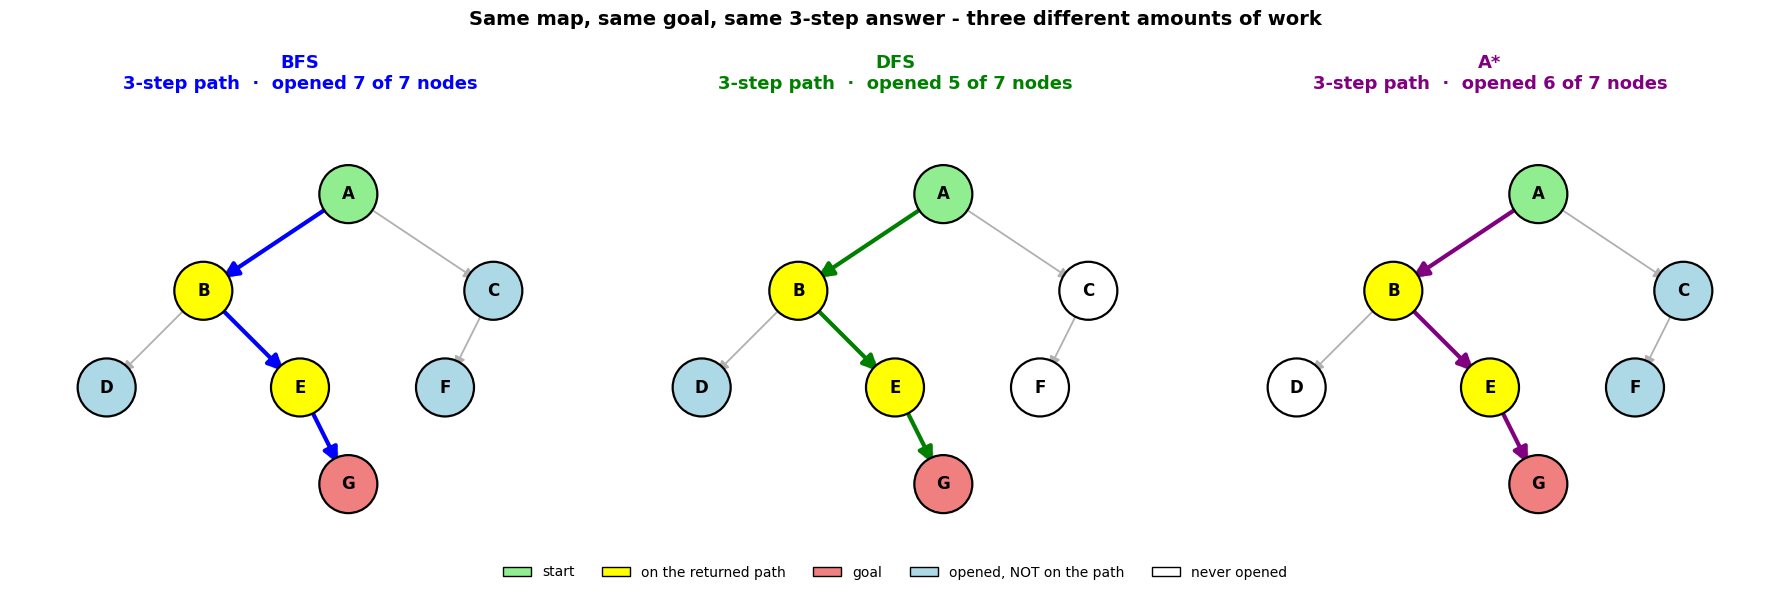


📊 ALGORITHM COMPARISON

Algorithm  Path Found   Path Length  Nodes Explored 
----------------------------------------------------------------------
BFS        Yes          3            7              
DFS        Yes          3            5              
A*         Yes          3            6              

✅ Key Differences:
   - BFS: Explores level by level, guarantees shortest path
   - DFS: Goes deep first, may not find shortest path
   - A*: Uses heuristic to find optimal path efficiently


In [12]:
# Compare all three algorithms side by side
# WHAT this cell does: runs BFS, DFS and A* on the SAME graph and draws all three results at the
#   same scale, with the same node coordinates, so the only thing that can differ between the
#   panels is the algorithm.
# WHY the panel titles carry TWO numbers: on this map all three return the same 3-step path, so
#   'path length' cannot tell them apart. The number that CAN is how many nodes each one had to
#   open to get there - which is why it is printed in the title and shaded into the picture.
def compare_algorithms(graph, start, goal):
    """
    Compare BFS, DFS, and A* algorithms.
    Shows their different exploration patterns.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    positions = {
        'A': (3, 3), 'B': (1.5, 2), 'C': (4.5, 2),
        'D': (0.5, 1), 'E': (2.5, 1), 'F': (4, 1), 'G': (3, 0)
    }
    
    # Get paths from each algorithm
    # BFS
    _, bfs_order = bfs_with_visualization(graph, start, goal)
    # DFS
    dfs_path, dfs_order = dfs_with_visualization(graph, start, goal)
    # A*
    astar_path, _, astar_order = astar_with_visualization(graph, start, goal)
    
    algorithms = [
        ("BFS", bfs_path, bfs_order, 'blue'),
        ("DFS", dfs_path, dfs_order, 'green'),
        ("A*", astar_path, astar_order, 'purple')
    ]
    
    for idx, (name, path, order, color) in enumerate(algorithms):
        ax = axes[idx]
        
        # Draw all edges
        for node, neighbors in graph.items():
            x1, y1 = positions[node]
            for neighbor in neighbors:
                x2, y2 = positions[neighbor]
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='-|>', color='#b0b0b0', lw=1.3,
                                           mutation_scale=16, shrinkA=16, shrinkB=16))
        
        # Highlight path
        if path:
            for i in range(len(path) - 1):
                x1, y1 = positions[path[i]]
                x2, y2 = positions[path[i+1]]
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                           arrowprops=dict(arrowstyle='-|>', color=color, lw=3,
                                           mutation_scale=22, shrinkA=17, shrinkB=17))
        
        # Color nodes by the role they ended up playing in THIS algorithm's run.
        for node, (x, y) in positions.items():
            if path and node in path:
                # start / goal / on the returned path
                node_color = 'lightgreen' if node == start else ('lightcoral' if node == goal else 'yellow')
            elif node in order:
                node_color = 'lightblue'   # opened, but not part of the answer = wasted work
            else:
                node_color = 'white'       # never opened at all
            # facecolor and edgecolor MUST be passed separately: a single color= silently overrides
            # the rim, and a white node with no rim is invisible on a white page.
            ax.add_patch(plt.Circle((x, y), 0.3, facecolor=node_color, edgecolor='black',
                                    lw=1.6, zorder=5))
            ax.text(x, y, node, ha='center', va='center', fontsize=12, fontweight='bold', zorder=6)
        
        ax.set_xlim(-0.5, 5.5)
        ax.set_ylim(-0.5, 4)
        ax.set_aspect('equal')
        ax.axis('off')
        path_length = len(path) - 1 if path else 0
        ax.set_title(f"{name}\n{path_length}-step path  ·  opened {len(order)} of {len(graph)} nodes",
                     fontsize=13, fontweight='bold', color=color)
    
    legend = [
        mpatches.Patch(facecolor='lightgreen', edgecolor='black', label='start'),
        mpatches.Patch(facecolor='yellow', edgecolor='black', label='on the returned path'),
        mpatches.Patch(facecolor='lightcoral', edgecolor='black', label='goal'),
        mpatches.Patch(facecolor='lightblue', edgecolor='black', label='opened, NOT on the path'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='never opened'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=5, fontsize=10, frameon=False,
               bbox_to_anchor=(.5, .01))
    fig.suptitle("Same map, same goal, same 3-step answer - three different amounts of work",
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, .06, 1, .94])
    plt.show()
    
    # Print comparison table
    print("\n" + "=" * 70)
    print("📊 ALGORITHM COMPARISON")
    print("=" * 70)
    print(f"\n{'Algorithm':<10} {'Path Found':<12} {'Path Length':<12} {'Nodes Explored':<15}")
    print("-" * 70)
    print(f"{'BFS':<10} {'Yes':<12} {len(bfs_path)-1 if bfs_path else 'N/A':<12} {len(bfs_order):<15}")
    print(f"{'DFS':<10} {'Yes':<12} {len(dfs_path)-1 if dfs_path else 'N/A':<12} {len(dfs_order):<15}")
    print(f"{'A*':<10} {'Yes':<12} {len(astar_path)-1 if astar_path else 'N/A':<12} {len(astar_order):<15}")
    print("\n✅ Key Differences:")
    print("   - BFS: Explores level by level, guarantees shortest path")
    print("   - DFS: Goes deep first, may not find shortest path")
    print("   - A*: Uses heuristic to find optimal path efficiently")

print("\n📊 Comparing all three algorithms...")
compare_algorithms(graph, 'A', 'G')

### 🔎 Read the figure

**What to look for.** The three coloured routes are *identical*: `A → B → E → G`, three steps, in all three panels. Now stop looking at the routes and count the **white** circles instead — the nodes each algorithm never opened. BFS has none: it opened all 7. DFS left `C` and `F` white — 5 opened. A\* left `D` white — 6 opened. Same answer, three different amounts of work, and that difference is the entire subject of this part.

**What it proves.** On *this* map the answer is unique (there is only one route from `A` to `G`, as the very first figure showed), so no algorithm can beat another on quality here — they can only be separated by effort. The blue circles are the honest measure of that effort: every light-blue node is a node the algorithm paid to open and got nothing back for.

**What it does NOT prove.** DFS opening the fewest nodes is *not* evidence that DFS is the efficient choice. It won here by guessing the correct branch first. Change `graph['A']` to `['C', 'B']` and DFS walks the dead-end branch first instead — the maze at the end of this notebook is exactly that situation, and there DFS returns a route two steps longer than BFS's. One example is never a benchmark.

## Part 7: Algorithm Complexity Analysis

**Why Complexity Matters**: Understanding time and space complexity helps us choose the right algorithm for the problem!

In [13]:
# Complexity Analysis of Search Algorithms
# This shows WHY different algorithms are used in different situations

print("=" * 70)
print("📊 ALGORITHM COMPLEXITY ANALYSIS")
print("=" * 70)
print("\nUnderstanding complexity helps us choose the right algorithm!")
print()

# Store each algorithm's time/space complexity and its best use case in one dict.
complexities = {
    'BFS': {
        'time': 'O(V + E)', 'space': 'O(V)',
        'explanation': 'Visits each vertex and edge once, uses queue',
        'best_for': 'Unweighted graphs, shortest path (in edges)'
    },
    'DFS': {
        'time': 'O(V + E)', 'space': 'O(V)',
        'explanation': 'Visits each vertex and edge once, uses stack (recursion)',
        'best_for': 'Pathfinding, backtracking, memory-efficient'
    },
    'A*': {
        'time': 'O(b^d) worst case', 'space': 'O(b^d)',
        'explanation': 'Depends on heuristic quality, explores fewer nodes than BFS',
        'best_for': 'Weighted graphs with good heuristic'
    },
    "Dijkstra's": {
        'time': 'O((V + E) log V)', 'space': 'O(V)',
        'explanation': 'Uses priority queue, guarantees optimal path',
        'best_for': 'Weighted graphs, no heuristic needed'
    }
}

print("📋 Complexity Comparison:\n")
print(f"{'Algorithm':<12} {'Time Complexity':<20} {'Space Complexity':<18} {'Best For'}")
print("-" * 80)

# Print the dict as an aligned table so the trade-offs sit side by side.
for algo, info in complexities.items():
    print(f"{algo:<12} {info['time']:<20} {info['space']:<18} {info['best_for']}")

print("\n🔑 Key Insights:")
print("   • BFS: Best for unweighted shortest path")
print("   • DFS: Best when memory is limited")
print("   • A*: Best with good heuristic (fast)")
print("   • Dijkstra: Best for weighted graphs (guaranteed optimal)")
print()
print("📊 Where V = number of vertices, E = number of edges")
print("   b = branching factor, d = depth of solution")

📊 ALGORITHM COMPLEXITY ANALYSIS

Understanding complexity helps us choose the right algorithm!

📋 Complexity Comparison:

Algorithm    Time Complexity      Space Complexity   Best For
--------------------------------------------------------------------------------
BFS          O(V + E)             O(V)               Unweighted graphs, shortest path (in edges)
DFS          O(V + E)             O(V)               Pathfinding, backtracking, memory-efficient
A*           O(b^d) worst case    O(b^d)             Weighted graphs with good heuristic
Dijkstra's   O((V + E) log V)     O(V)               Weighted graphs, no heuristic needed

🔑 Key Insights:
   • BFS: Best for unweighted shortest path
   • DFS: Best when memory is limited
   • A*: Best with good heuristic (fast)
   • Dijkstra: Best for weighted graphs (guaranteed optimal)

📊 Where V = number of vertices, E = number of edges
   b = branching factor, d = depth of solution


depth  nodes in tree  BFS peak queue  DFS peak stack
------------------------------------------------------
    2              3               2               2
    3              7               4               3
    4             15               8               4
    5             31              16               5
    6             63              32               6
    7            127              64               7
    8            255             128               8
    9            511             256               9
   10          1,023             512              10
   11          2,047           1,024              11
   12          4,095           2,048              12
   13          8,191           4,096              13
   14         16,383           8,192              14


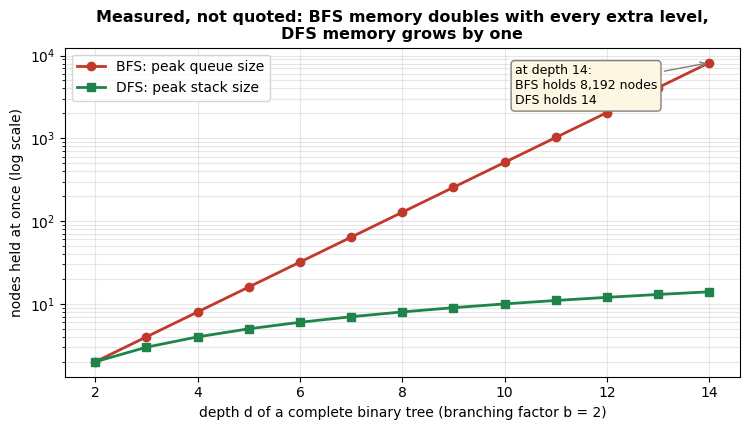

In [14]:
# FIGURE: the complexity table above is quoted. This cell MEASURES the row that hurts most.
# WHAT this cell does: builds complete binary trees of depth 2..14, runs BFS and DFS over each,
#   and records the PEAK frontier size - the largest number of nodes held in memory at one time.
# WHY the frontier and not the visited set: both algorithms end up remembering every node they
#   visited, so that part is a tie. The difference that decides whether a search fits in RAM is
#   how big the waiting list gets, and that is where BFS and DFS part company completely.
import matplotlib.pyplot as plt


def complete_binary_tree(depth):
    """Nodes numbered 1..2^depth-1; node i has children 2i and 2i+1. b = 2 by construction."""
    tree = {}
    for node in range(1, 2 ** depth):
        tree[node] = [2 * node, 2 * node + 1] if 2 * node + 1 < 2 ** depth else []
    return tree


def peak_frontier(tree, take_from_end):
    """Traverse the whole tree and return the largest frontier ever held.

    take_from_end=False -> pop(0), FIFO  -> this IS breadth-first search.
    take_from_end=True  -> pop(),  LIFO  -> this IS depth-first search.
    One function, one flag: the ONLY difference between the two curves below is which end of
    the frontier we take from.
    """
    frontier, seen, peak = [1], {1}, 1
    while frontier:
        node = frontier.pop() if take_from_end else frontier.pop(0)
        for child in tree.get(node, []):
            if child not in seen:
                seen.add(child)
                frontier.append(child)
        peak = max(peak, len(frontier))
    return peak


depths = list(range(2, 15))
bfs_peaks, dfs_peaks = [], []
for depth in depths:
    tree = complete_binary_tree(depth)
    bfs_peaks.append(peak_frontier(tree, take_from_end=False))
    dfs_peaks.append(peak_frontier(tree, take_from_end=True))

print(f"{'depth':>5}  {'nodes in tree':>13}  {'BFS peak queue':>14}  {'DFS peak stack':>14}")
print("-" * 54)
for depth, bfs_peak, dfs_peak in zip(depths, bfs_peaks, dfs_peaks):
    print(f"{depth:>5}  {2 ** depth - 1:>13,}  {bfs_peak:>14,}  {dfs_peak:>14}")

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.semilogy(depths, bfs_peaks, 'o-', color="#c0392b", lw=2, label="BFS: peak queue size")
ax.semilogy(depths, dfs_peaks, 's-', color="#1e8449", lw=2, label="DFS: peak stack size")
ax.set_xlabel("depth d of a complete binary tree (branching factor b = 2)")
ax.set_ylabel("nodes held at once (log scale)")
ax.set_title("Measured, not quoted: BFS memory doubles with every extra level,\n"
             "DFS memory grows by one", fontsize=11.5, fontweight='bold')
ax.grid(alpha=.3, which='both')
ax.legend(loc='upper left')
ax.annotate(f"at depth {depths[-1]}:\nBFS holds {bfs_peaks[-1]:,} nodes\nDFS holds {dfs_peaks[-1]}",
            xy=(depths[-1], bfs_peaks[-1]), xytext=(-140, -30), textcoords='offset points',
            fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'),
            bbox=dict(boxstyle='round', fc='#fdf6e3', ec='gray'))
plt.tight_layout()
plt.show()


### 🔎 Read the figure

**What to look for.** The vertical axis is logarithmic, so a *straight* line means *exponential*
growth. The red BFS line is straight: every extra level of depth doubles the queue. The green DFS
line bends flat almost immediately — it grows by roughly one node per level. At the right-hand edge
the annotation gives the gap on this measurement: BFS holds **8,192** nodes at once where DFS holds
**14**. Check it against the printed table; the two agree because the figure is drawn from it.

**What it proves.** The complexity table above gives BFS and DFS the same `O(V)` space, and for the
*visited set* that is right — both eventually remember everything they saw. But the number that
decides whether a search fits in memory is the **frontier**, the waiting list, and there the two are
not remotely alike: `b^d` against `b·d`. The one-flag `peak_frontier` function makes the cause
unmistakable — the only difference between the two curves is `pop()` versus `pop(0)`, which end of
the frontier you take from.

**Why this is the practical bullet.** This is the ⚠️ "BFS's wall is memory, not speed" claim, measured.
Extrapolate the red line to a city road network with a branching factor near 3 and a depth in the
hundreds and the queue stops being a data structure and starts being a hardware purchase. That is why
production routing preprocesses the graph instead of searching harder.

In [15]:
# Real-World Applications of Search Algorithms

print("=" * 70)
print("🌍 REAL-WORLD APPLICATIONS OF SEARCH ALGORITHMS")
print("=" * 70)
print()

# Why: complexity tables feel abstract - mapping each algorithm to real products shows when you would actually reach for it.
# Collect real-world uses per algorithm in a dict of lists.
applications = {
    'BFS': [
        "🗺️  GPS Navigation: Finding shortest route (by number of turns)", "🌐 Web Crawling: Indexing web pages level by level",
        "🎮 Game AI: Pathfinding in games (e.g., finding path around obstacles)",
        "📡 Network Routing: Broadcasting messages in networks"
    ],
    'DFS': [
        "🔍 Puzzle Solving: Solving mazes, Sudoku (backtracking)",
        "🌳 Tree Traversal: File system navigation",
        "🔗 Topological Sorting: Task scheduling",
        "🎯 Cycle Detection: Detecting cycles in graphs"
    ],
    'A*': [
        "🚗 GPS Navigation: Optimal route finding (distance + time)",
        "🤖 Robotics: Path planning for robots",
        "🎮 Game AI: NPC movement in games (e.g., strategy games)",
        "🗺️  Map Applications: Google Maps route finding"
    ],
    "Dijkstra's": [
        "🌐 Network Routing: OSPF, IS-IS routing protocols",
        "🚗 GPS Systems: Finding shortest path considering traffic",
        "📡 Internet Routing: Packet routing in networks",
        "🚦 Traffic Management: Optimizing traffic flow"
    ]
}

# Print each algorithm with its applications underneath.
for algo, apps in applications.items():
    print(f"📓 {algo} Applications:")
    for app in apps:
        print(f"   {app}")
    print()

print("💡 Key Takeaway:")
print("   Different algorithms solve different real-world problems!")
print("   Understanding when to use each algorithm is crucial!")

🌍 REAL-WORLD APPLICATIONS OF SEARCH ALGORITHMS

📓 BFS Applications:
   🗺️  GPS Navigation: Finding shortest route (by number of turns)
   🌐 Web Crawling: Indexing web pages level by level
   🎮 Game AI: Pathfinding in games (e.g., finding path around obstacles)
   📡 Network Routing: Broadcasting messages in networks

📓 DFS Applications:
   🔍 Puzzle Solving: Solving mazes, Sudoku (backtracking)
   🌳 Tree Traversal: File system navigation
   🔗 Topological Sorting: Task scheduling
   🎯 Cycle Detection: Detecting cycles in graphs

📓 A* Applications:
   🚗 GPS Navigation: Optimal route finding (distance + time)
   🤖 Robotics: Path planning for robots
   🎮 Game AI: NPC movement in games (e.g., strategy games)
   🗺️  Map Applications: Google Maps route finding

📓 Dijkstra's Applications:
   🌐 Network Routing: OSPF, IS-IS routing protocols
   🚗 GPS Systems: Finding shortest path considering traffic
   📡 Internet Routing: Packet routing in networks
   🚦 Traffic Management: Optimizing traffic flow

## 💬 Discuss

Argue these out loud. None has a single right answer, and each is answerable from the output above.

1. **Read the DFS trace again.** It reached G, and it reached it by a longer route than BFS — it walked into D, hit a dead end and backtracked. Your team ships a game whose guards path with DFS because it uses far less memory. A tester files: *"the guards walk stupidly."* Is that a bug or a design decision? What would you tell the producer, and what specific evidence would change your mind?
2. **Our `heuristic(node, goal)` is the alphabetical gap between letters.** It has nothing whatever to do with the graph's real edge costs — it just happens not to mislead us here. What property must a heuristic have for A\* to keep its optimality guarantee, and can you invent a plausible-sounding heuristic for a Riyadh delivery run that violates it? (Hint: think about a rule based on district names, or on customer priority.)
3. **The complexity table says BFS costs O(b^d) in space, DFS O(bd).** Which failure would you rather explain to a client: a warehouse robot that runs out of memory halfway through planning and stops dead, or one that always finishes but sometimes takes a route 30% longer than necessary? Name the application you have in mind — the answer flips depending on it.

---


## ⚠️ Where this breaks

Everything above works. Here is exactly when it stops working.

- **A\* is optimal only if the heuristic never overestimates.** That is the *admissibility* condition Hart, Nilsson and Raphael proved. Feed A\* a heuristic that overshoots and it will still return a path, still return it quickly, and give you no warning that it is not the shortest. On real maps the safe default is straight-line distance, precisely because no road can be shorter than the straight line between two points.
- **BFS's wall is memory, not speed.** BFS holds an entire frontier: roughly b^d nodes at depth d. On the 4×4 maze in Part 9 that is trivial. On a city road graph it is millions of nodes held simultaneously — which is why the memory column of that complexity table matters more in practice than the time column.
- **Nobody runs plain Dijkstra on a country.** Production routing engines such as OSRM spend *hours* preprocessing the road network into contraction hierarchies or a multi-level overlay, then answer a continental query in milliseconds using bidirectional Dijkstra over the augmented graph. What you implemented is the correct core and the wrong deployment. If your graph is big and your queries are many, the answer is preprocessing, not a faster loop.
- **The graph must be known, and it must hold still.** Every algorithm here assumes the edges and their costs are fixed and fully known. Roadworks, a traffic jam, a toll that changes by the hour, a warehouse aisle that is blocked right now — those make it a *time-dependent* routing problem, and re-running the search after every change is usually too expensive to do naively.
- **The cheaper alternative.** On a small unweighted graph, BFS already gives you the optimal answer with no heuristic to get wrong. Add A\* when a search is *measurably* too slow — not because it sounds more intelligent. A bad heuristic is strictly worse than no heuristic.

---


## Summary

### What We Learned

**BEFORE this notebook**: 
- ❌ No systematic way to search graphs
- ❌ No understanding of different search strategies
- ❌ No visualization tools

**AFTER this notebook**:
- ✅ **BFS**: Level-by-level exploration, shortest path guaranteed
- ✅ **DFS**: Deep-first exploration, memory efficient
- ✅ **A***: Intelligent search using heuristics, optimal and efficient
- ✅ **Visualizations**: See exactly how each algorithm works!

### Python Concepts Used:
1. **Data Structures**: Lists, dictionaries, sets, deques
2. **Queue (FIFO)**: Used in BFS
3. **Stack (LIFO)**: Used in DFS (via recursion)
4. **Priority Queue**: Used in A* (via heapq)
5. **Visualization**: Matplotlib for graphs

### 🔗 How This Connects to Other Notebooks:

**What you learned here will be used in:**
- **Notebook 2: Knowledge Representation** - Uses graph concepts (nodes, edges) you learned here. Knowledge graphs are just graphs where nodes are entities and edges are relationships!

- **Notebook 4: Optimization Techniques** - Search algorithms are optimization problems! Finding the best path is like finding the optimal solution. A* uses optimization concepts (minimizing cost).

- **Notebook 5: AI Learning Models** - Understanding algorithms (like search) helps you understand how ML models work - they're also algorithms that search for patterns!

**Why this order?**
1. Search algorithms teach you **graph concepts** needed for knowledge representation
2. Search algorithms teach you **algorithmic thinking** needed for all AI
3. Search algorithms show you **problem-solving strategies** used throughout AI

### Real-World Applications:
- 🎮 **Game AI**: Pathfinding for NPCs (non-player characters) to navigate game worlds
- 🤖 **Robotics**: Navigation systems for robots to find paths while avoiding obstacles
- 🗺️ **GPS Navigation**: Finding optimal routes between locations
- 🌐 **Web Crawling**: Systematically exploring websites and links
- 🔍 **Puzzle Solving**: Finding solutions to problems like Rubik's cube, mazes, and puzzles
- 📊 **Network Analysis**: Finding shortest paths in social networks, communication networks

### Key Takeaways:
1. **Different algorithms for different needs**: BFS for shortest path, DFS for memory efficiency, A* for intelligent search
2. **Graph representation matters**: How you represent the graph affects algorithm efficiency
3. **Visualization helps understanding**: Seeing algorithms work makes concepts clearer
4. **Foundation for AI**: Search algorithms are fundamental - many AI techniques build on these concepts

## Part 9: Practice Exercises

**The Story**: Now that we understand the algorithms, let's practice! Practice helps us truly master the concepts.

**BEFORE**: We watched algorithms work, but haven't tried them ourselves.
**AFTER**: We'll solve problems using what we learned - this cements our understanding!

In [16]:
# Practice Exercise: Solve a Maze Using Different Algorithms
# This exercise helps you understand how each algorithm works differently!

def create_practice_maze():
    """
    Create a practice maze for solving.
    
    Problem: Find path from start to goal in this maze.
    Solution: Use different search algorithms and compare!
    """
    maze_graph = {
        (0, 0): [(0, 1), (1, 0)],  # Start position
        (0, 1): [(0, 0), (0, 2)],
        (0, 2): [(0, 1), (1, 2)],
        (1, 0): [(0, 0), (2, 0)],
        (1, 2): [(0, 2), (2, 2)],
        (2, 0): [(1, 0), (2, 1)],
        (2, 1): [(2, 0), (2, 2), (3, 1)],
        (2, 2): [(1, 2), (2, 1), (3, 2)],
        (3, 1): [(2, 1), (3, 2)],
        (3, 2): [(2, 2), (3, 1), (3, 3)],
        (3, 3): [(3, 2)]  # Goal position
    }
    return maze_graph

print("=" * 70)
print("🎯 PRACTICE EXERCISE: Maze Solving")
print("=" * 70)
print("\n📝 Problem: Solve the maze using different algorithms")
print("   Start: (0, 0)")
print("   Goal: (3, 3)")
print()

# Build the maze graph, then solve it three ways and compare the paths found.
maze = create_practice_maze()

# Define simple search functions for practice exercise
# These are simplified versions of the full algorithms we learned earlier

def bfs(graph, start, goal):
    """Simple BFS implementation for practice exercise"""
    from collections import deque
    queue = deque([(start, [start])])
    visited = set()
    
    while queue:
        current, path = queue.popleft()
        if current == goal:
            return path
        if current not in visited:
            visited.add(current)
            for neighbor in graph.get(current, []):
                if neighbor not in visited:
                    queue.append((neighbor, path + [neighbor]))
    return None

def dfs(graph, start, goal, visited=None, path=None):
    """Simple DFS implementation for practice exercise"""
    if visited is None:
        visited = set()
    if path is None:
        path = []
    
    visited.add(start)
    path = path + [start]
    
    if start == goal:
        return path, visited
    
    for neighbor in graph.get(start, []):
        if neighbor not in visited:
            result, _ = dfs(graph, neighbor, goal, visited, path)
            if result:
                return result, visited
    
    return None, visited

def astar(graph, start, goal):
    """Simple A* implementation for practice exercise"""
    import heapq
    
    def heuristic(node, goal):
        """Manhattan distance heuristic for grid-based maze"""
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])
    
    open_set = [(heuristic(start, goal), 0, start, [start])]  # f(start) = 0 + h(start)
    visited = set()
    g_scores = {start: 0}
    
    while open_set:
        f_score, g_score, current, path = heapq.heappop(open_set)
        
        if current == goal:
            return path, visited
        
        if current in visited:
            continue
        
        visited.add(current)
        
        for neighbor in graph.get(current, []):
            if neighbor in visited:
                continue
            
            tentative_g = g_score + 1  # Edge cost = 1 for all edges
            h_score = heuristic(neighbor, goal)
            f_score = tentative_g + h_score
            
            if neighbor not in g_scores or tentative_g < g_scores[neighbor]:
                g_scores[neighbor] = tentative_g
                heapq.heappush(open_set, (f_score, tentative_g, neighbor, path + [neighbor]))
    
    return None, visited

# Try BFS
print("🔍 Using BFS:")
bfs_path = bfs(maze, (0, 0), (3, 3))
print(f"   Path: {bfs_path}")
print(f"   Path length: {len(bfs_path) - 1} steps")

# Try DFS
print("\n🔍 Using DFS:")
dfs_path, _ = dfs(maze, (0, 0), (3, 3))
print(f"   Path: {dfs_path}")
print(f"   Path length: {len(dfs_path) - 1} steps")

# Try A*
print("\n🔍 Using A*:")
astar_path, _ = astar(maze, (0, 0), (3, 3))
print(f"   Path: {astar_path}")
print(f"   Path length: {len(astar_path) - 1} steps")

print("\n📊 Comparison:")
print(f"   BFS found path of length: {len(bfs_path) - 1 if bfs_path else 'N/A'}")
print(f"   DFS found path of length: {len(dfs_path) - 1 if dfs_path else 'N/A'}")
print(f"   A* found path of length: {len(astar_path) - 1 if astar_path else 'N/A'}")
print("\n💡 Practice Questions:")
print("   1. Why might paths differ between algorithms?")
print("   2. Which algorithm always finds the shortest path (in edges)?")
print("   3. Which algorithm is most memory-efficient?")

🎯 PRACTICE EXERCISE: Maze Solving

📝 Problem: Solve the maze using different algorithms
   Start: (0, 0)
   Goal: (3, 3)

🔍 Using BFS:
   Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
   Path length: 6 steps

🔍 Using DFS:
   Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (3, 1), (3, 2), (3, 3)]
   Path length: 8 steps

🔍 Using A*:
   Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
   Path length: 6 steps

📊 Comparison:
   BFS found path of length: 6
   DFS found path of length: 8
   A* found path of length: 6

💡 Practice Questions:
   1. Why might paths differ between algorithms?
   2. Which algorithm always finds the shortest path (in edges)?
   3. Which algorithm is most memory-efficient?


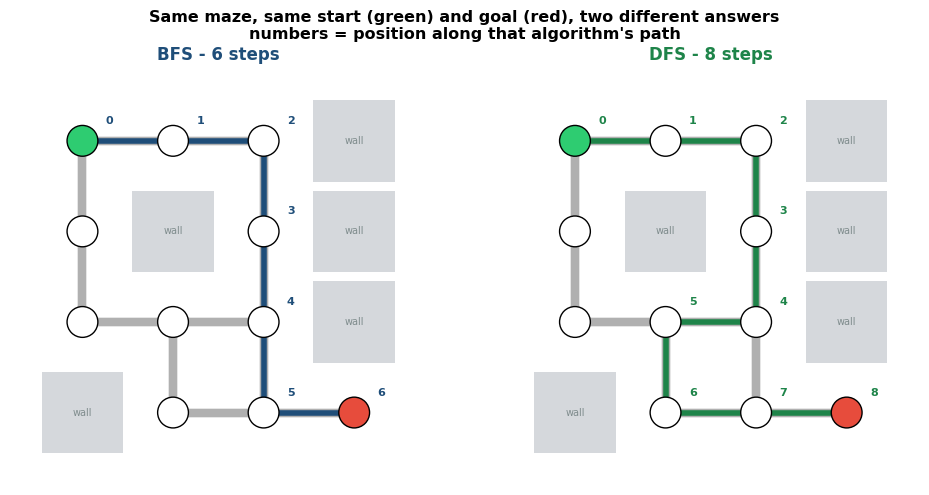

BFS route: 6 steps   [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
DFS route: 8 steps   [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (3, 1), (3, 2), (3, 3)]
A* route : 6 steps   [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]

Cells DFS walked that BFS did not: [(2, 1), (3, 1)]


In [17]:
# FIGURE: the BFS and DFS routes printed above as coordinate tuples, drawn as actual routes.
# WHAT this cell does: draws the practice maze twice - once with the BFS route, once with DFS -
#   numbering each step along the way so the detour is countable, not just assertable.
# WHY: "BFS 6 steps, DFS 8 steps" is a pair of numbers. WHERE the two extra steps went is a
#   picture, and it is the picture that explains why DFS produced them.
import matplotlib.pyplot as plt

# Grid coordinates are (row, col). Plot with x = col and y = -row so row 0 sits at the top,
# which is how the maze reads on the page.
to_xy = lambda cell: (cell[1], -cell[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, path, color) in zip(axes, [("BFS", bfs_path, "#1f4e79"),
                                          ("DFS", dfs_path, "#1e8449")]):
    # Grid positions that are NOT in the maze dictionary are walls.
    for row in range(4):
        for col in range(4):
            if (row, col) not in maze:
                ax.add_patch(plt.Rectangle((col - .45, -row - .45), .9, .9,
                                           facecolor="#d5d8dc", edgecolor="none"))
                ax.text(col, -row, "wall", fontsize=7, ha='center', va='center', color='#7f8c8d')

    # Every corridor the maze offers, in grey - the options the algorithm had.
    for cell, neighbours in maze.items():
        for neighbour in neighbours:
            x1, y1 = to_xy(cell)
            x2, y2 = to_xy(neighbour)
            ax.plot([x1, x2], [y1, y2], color="#b0b0b0", lw=6, solid_capstyle='round', zorder=1)

    # The route this algorithm actually returned, in colour, with step numbers.
    ax.plot([to_xy(c)[0] for c in path], [to_xy(c)[1] for c in path],
            color=color, lw=4, zorder=3, solid_capstyle='round')
    for i, cell in enumerate(path):
        x, y = to_xy(cell)
        ax.text(x + .30, y + .22, str(i), fontsize=8, ha='center', va='center', color=color,
                fontweight='bold', zorder=7,
                bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=.85))

    for cell in maze:
        x, y = to_xy(cell)
        face = "#2ecc71" if cell == (0, 0) else ("#e74c3c" if cell == (3, 3) else "white")
        ax.add_patch(plt.Circle((x, y), .17, facecolor=face, edgecolor='black', lw=1, zorder=5))

    ax.set_xlim(-.8, 3.8)
    ax.set_ylim(-3.8, .8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"{name} - {len(path) - 1} steps", fontsize=12, fontweight='bold', color=color)

fig.suptitle("Same maze, same start (green) and goal (red), two different answers\n"
             "numbers = position along that algorithm's path",
             fontsize=11.5, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"BFS route: {len(bfs_path) - 1} steps   {bfs_path}")
print(f"DFS route: {len(dfs_path) - 1} steps   {dfs_path}")
print(f"A* route : {len(astar_path) - 1} steps   {astar_path}")
print(f"\nCells DFS walked that BFS did not: {sorted(set(dfs_path) - set(bfs_path))}")


### 🔎 Read the figure

**What to look for.** Both routes start green at the top-left and are identical for their first four
moves, down to the cell at step 4. Then they split. BFS drops straight down and reaches the red goal
at step 6. DFS turns **left** into `(2,1)`, down to `(3,1)`, and only then comes back right to the
goal — a visible three-sided detour, arriving at step 8. The cells in that bulge are exactly the ones
the last printed line names.

**What it proves.** DFS's answer is not wrong — it is a real path through the maze. It is simply
*not the shortest*, and DFS has no mechanism that would ever notice. It committed to the first
neighbour it could reach, and it returns the first complete path it stumbles into. BFS could not
return an 8-step path while a 6-step path existed, because it finishes every 6-step candidate before
it starts on a 7th step. A\* matched BFS here — and on this grid it deserves the credit, because the
Manhattan-distance heuristic it uses cannot overestimate the true cost when every move costs 1 (unlike
the toy alphabetical heuristic in Part 4).

**The take-away for the exercise questions below.** Question 1 asks why the paths differ: they differ
because *the order the frontier is drained in is the algorithm*. Take from the front and you get
level-by-level and the shortest path; take from the back and you get depth-first and the first path
that works.

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

Graph search never left; it moved up a level. The most-discussed "search" in AI in 2026 is not over map nodes but over *candidate answers a model produces*: sample several attempts, score them, keep the best — and the live engineering question is how much compute to spend exploring before committing to an answer. Snell *et al.* (2024) showed that spending that compute well at inference time can beat training a larger model on the same budget, and Muennighoff *et al.* (2025) obtained much of the effect from *budget forcing*, which amounts to refusing to let the model stop early. That is the trade-off you just measured with your own instruments: BFS pays in frontier memory, DFS pays in wasted depth, A\* buys speed with a heuristic it cannot verify — each is a policy for spending a limited exploration budget. Learn the classical algorithms first, because they are where the vocabulary comes from (frontier, branching factor, admissible heuristic, optimality guarantee) and because on an actual graph — a road network, a warehouse aisle, a game tree — they remain the correct answer and cost a few milliseconds rather than a few thousand model calls.

**Read:** Snell *et al.* (2024), <https://arxiv.org/abs/2408.03314> · Muennighoff *et al.* (2025), <https://arxiv.org/abs/2501.19393> (references 5-6 below).

---

## 📚 References

1. Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). *A Formal Basis for the Heuristic Determination of Minimum Cost Paths*. IEEE Transactions on Systems Science and Cybernetics 4(2), 100-107. (the A* paper)
2. Dijkstra, E. W. (1959). *A Note on Two Problems in Connexion with Graphs*. Numerische Mathematik 1, 269-271.
3. Silver, D., et al. (2016). *Mastering the Game of Go with Deep Neural Networks and Tree Search*. Nature 529, 484-489. (AlphaGo: modern search combined with learning)
4. Schrittwieser, J., et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model*. Nature 588, 604-609. <https://arxiv.org/abs/1911.08265> (MuZero)
5. Snell, C., Lee, J., Xu, K., & Kumar, A. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. arXiv preprint. <https://arxiv.org/abs/2408.03314> (search as a compute budget: how much to spend exploring before you answer)
6. Muennighoff, N., et al. (2025). *s1: Simple test-time scaling*. arXiv preprint. <https://arxiv.org/abs/2501.19393> ("budget forcing" — the crudest possible way to make a model keep searching, and it works)
7. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chapters 3-4 (Solving Problems by Searching; Search in Complex Environments). Pearson. <https://aima.cs.berkeley.edu/>